# EDA - Atividade extensionista

## 1. Bibliotecas e leitura do arquivo

In [1221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
from itertools import combinations
from sklearn.metrics import roc_auc_score, roc_curve
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment

In [ ]:
df = pd.read_csv('eng_amb_ns_tab_unificada.csv')

In [ ]:
df.shape

## 2. Metadados

In [ ]:
def generate_metadata(dataframe):
    """
    Gera um dataframe contendo metadados das colunas do dataframe fornecido.

    :param dataframe: DataFrame para o qual os metadados serão gerados.
    :return: DataFrame contendo metadados.
    """

    # Coleta de metadados básicos
    metadata = pd.DataFrame({
        'nome_variavel': dataframe.columns,
        'tipo': dataframe.dtypes,
        'qt_nulos': dataframe.isnull().sum(),
        'percent_nulos': round((dataframe.isnull().sum() / len(dataframe))* 100,2),
        'cardinalidade': dataframe.nunique(),
    })
    metadata=metadata.sort_values(by='tipo')
    metadata = metadata.reset_index(drop=True)

    return metadata

metadata_df = generate_metadata(df)
metadata_df

### Tratamento de dados

### 3.1 Tipo dos dados

#### matricula

In [ ]:
# Converter matricula de float64 para object (string)
# É um identificador de período, não um valor numérico
df['matricula'] = df['matricula'].astype(str)

# Verificar resultado
print(df['matricula'].dtype)
print(df['matricula'].head(3))

#### prazo_conclusao

In [ ]:
# Converter prazo_conclusao de float64 (ex: 2028.1) para string formatada 'AAAA.S'
df['prazo_conclusao'] = df['prazo_conclusao'].apply(
    lambda x: f"{int(x)}.{int(round((x % 1) * 10))}" if pd.notna(x) else np.nan
    # int(x)            → extrai o ano (parte inteira)
    # (x % 1) * 10      → isola o decimal e converte para semestre (0.1 → 1, 0.2 → 2)
    # round()           → evita imprecisão de ponto flutuante (ex: 0.09999... → 0.1)
    # pd.notna(x)       → preserva nulos como np.nan em vez de converter para 'nan'
)

# Verificar resultado
print(df['prazo_conclusao'].dtype)
print(df['prazo_conclusao'].head(3))

In [ ]:
# Extrair componentes numéricos de prazo_conclusao para uso em cálculos futuros
# Exemplo de uso: quantos semestres faltavam quando o aluno cancelou a matrícula

# Ano previsto de conclusão (ex: '2028.1' → 2028)
df['prazo_conclusao_ano'] = (
    df['prazo_conclusao']
    .str.split('.')           # separa '2028.1' em ['2028', '1']
    .str[0]                   # pega o primeiro elemento → '2028'
    .astype('Int64')          # converte para inteiro nullable (suporta nulos)
)

# Semestre previsto de conclusão (ex: '2028.1' → 1)
df['prazo_conclusao_semestre'] = (
    df['prazo_conclusao']
    .str.split('.')           # separa '2028.1' em ['2028', '1']
    .str[1]                   # pega o segundo elemento → '1'
    .astype('Int64')          # converte para inteiro nullable (suporta nulos)
)

# Verificar resultado
print(df[['prazo_conclusao', 'prazo_conclusao_ano', 'prazo_conclusao_semestre']].head(3))
print(f"\nTipo prazo_conclusao_ano      : {df['prazo_conclusao_ano'].dtype}")
print(f"Tipo prazo_conclusao_semestre : {df['prazo_conclusao_semestre'].dtype}")

#### ensino_medio_conclusao

In [ ]:
# Converter ensino_medio_ano_concl de float64 para inteiro nullable
# Int64 (nullable) pois a coluna pode conter nulos
df['ensino_medio_ano_concl'] = df['ensino_medio_ano_concl'].astype('Int64')

# Verificar resultado
print(df['ensino_medio_ano_concl'].dtype)
print(df['ensino_medio_ano_concl'].head(3))

### Criar colunas

#### Target

In [ ]:
# Criar coluna target binária a partir de situacao_matricula
# 1 = evadiu (CANCELADO), 0 = não evadiu (todos os demais)
# Usa Int64 nullable para manter consistência com as demais colunas inteiras do df
df['target'] = (df['situacao_matricula'] == 'CANCELADO').astype('Int64')

# Verificar resultado
print(df['target'].value_counts(dropna=False))
print(f"\nTipo: {df['target'].dtype}")

#### idade_ingresso

In [ ]:
# Dicionário para converter mês em português
meses_pt = {
    'janeiro': 1, 'fevereiro': 2, 'março': 3, 'abril': 4,
    'maio': 5, 'junho': 6, 'julho': 7, 'agosto': 8,
    'setembro': 9, 'outubro': 10, 'novembro': 11, 'dezembro': 12
}

def parse_data_nascimento(data_str):
    try:
        partes = data_str.split(', ')
        mes_dia = partes[1].split(' ')
        mes = meses_pt[mes_dia[0].lower()]
        dia = int(mes_dia[1])
        ano = int(partes[2])
        return pd.Timestamp(year=ano, month=mes, day=dia)
    except:
        return pd.NaT

def parse_safra(safra_val):
    try:
        safra_str = str(safra_val)
        ano, sem = safra_str.split('.')
        mes = 1 if sem == '1' else 7
        return pd.Timestamp(year=int(ano), month=mes, day=1)
    except:
        return pd.NaT

# Criar as duas colunas auxiliares
df['data_nascimento_dt'] = df['data_nascimento'].apply(parse_data_nascimento)
df['safra_dt'] = df['safra'].apply(parse_safra)

# Calcular idade no ingresso
df['idade_ingresso'] = (
    (df['safra_dt'] - df['data_nascimento_dt']).dt.days // 365
)

df[['data_nascimento', 'safra', 'idade_ingresso']].sample(10)

#### Anos após a  conclusão do ensino médio

In [1281]:
# Calcula quantos anos se passaram entre a conclusão do ensino médio e o ingresso
df['anos_apos_em'] = (df['safra_ano'] - df['ensino_medio_ano_concl']).astype('Int64')

In [1282]:
print(df.columns.tolist())

['matricula', 'ano_disciplina', 'semestre_disciplina', 'curriculo', 'codigo_disciplina', 'disciplina', 'periodo', 'ch', 'disciplina_curso', 'tipo', 'nota_final', 'faltas', 'situacao_disciplina', 'ano_semestre_letivo', 'renovacao_matricula', 'cpf', 'nome', 'campus', 'curso', 'forma_ingresso', 'forma_ingresso_categoria', 'prazo_conclusao', 'sexo', 'nome_nacao', 'naturalidade_estado', 'naturalidade_municipio', 'data_nascimento', 'raca', 'ensino_medio_escola', 'tipo_escola', 'ensino_medio_ano_concl', 'data_ingresso', 'dataultimamovimentacao:_dia', 'tipoultimamovimentacao', 'necessidade_especial', 'rendimento_global', 'safra', 'situacao_matricula', 'percentual_ch_cumprida', 'data_trancamento_1', 'data_retorno_1', 'data_trancamento_2', 'data_retorno_2', 'qtd_trancamentos', 'prazo_conclusao_ano', 'prazo_conclusao_semestre', 'safra_ano', 'safra_semestre', 'target', 'ano_semestre_target', 'ano_target', 'semestre_target', 'ano_semestre_conclusao', 'ano_semestre_integralizado', 'idade_ingresso', 

#### Identificação do aluno

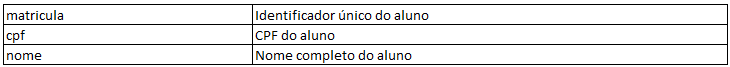

#### Perfil sociodemográfico

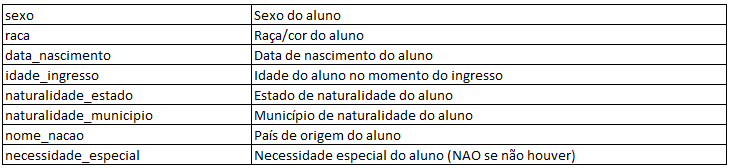

#### Ensino médio

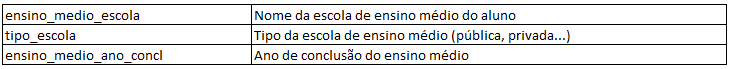

#### Safra

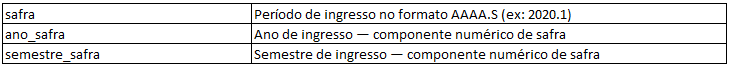

#### Ingresso e vínculo institucional

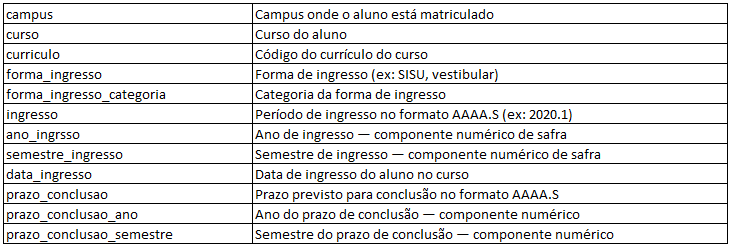

#### Situação e movimentação da matrícula

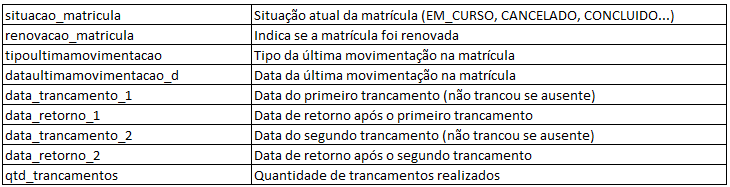

#### Desempenho acadêmico

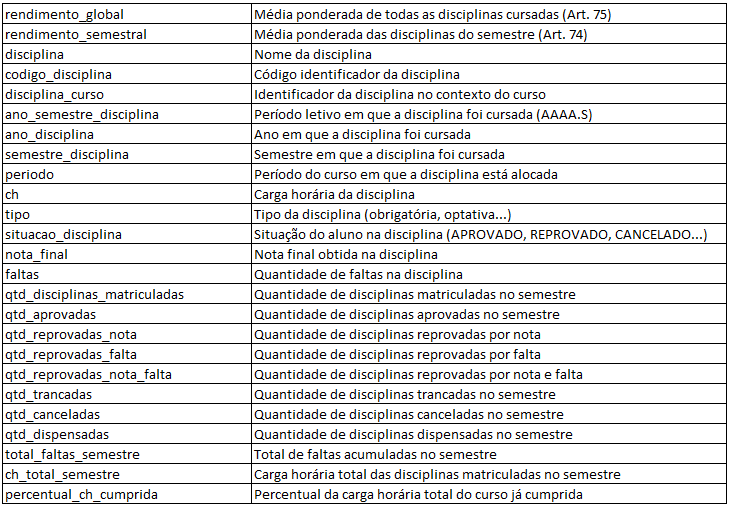

## 3. Análise exploratória de dados

In [ ]:
df.describe()

In [ ]:
df.info()

### Rendimento global

In [ ]:
plt.close('all')

# --- DataFrame: rendimento_global por aluno único ---
df_rend = (
    df
    .drop_duplicates('matricula')
    [['matricula', 'target', 'rendimento_global']]
    .dropna(subset=['rendimento_global'])
    .reset_index(drop=True)
)

# Separa os grupos por situação da matrícula
rend_cancelados     = df_rend[df_rend['target'] == 1]['rendimento_global']
rend_nao_cancelados = df_rend[df_rend['target'] == 0]['rendimento_global']

# Paleta de cores padrão do projeto
cores = {'Evadiram': '#d85a30', 'Permaneceram': '#3266ad'}

# --- Layout: boxplot em cima, histograma embaixo, eixo x compartilhado ---
fig = plt.figure(figsize=(10, 4))  # altura aumentada para acomodar a legenda
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)

ax_box  = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharex=ax_box)  # compartilha o eixo x com o boxplot

# ==============================
# PAINEL SUPERIOR — Boxplot
# ==============================
ax_box.grid(False)

bp = ax_box.boxplot(
    [rend_nao_cancelados, rend_cancelados],
    vert=False,
    patch_artist=True,       # necessário para colorir as caixas
    widths=0.7,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)

# Aplica cores às caixas (ordem: Permaneceram=1, Evadiram=2)
bp['boxes'][0].set_facecolor(cores['Permaneceram'])
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(cores['Evadiram'])
bp['boxes'][1].set_alpha(0.7)

# Rótulos do eixo y do boxplot
ax_box.set_yticks([1, 2])
ax_box.set_yticklabels(['Permaneceram', 'Evadiram'], fontsize=11)

# Remove bordas desnecessárias e oculta o eixo x (compartilhado com o histograma)
ax_box.spines[['top', 'right', 'bottom']].set_visible(False)
ax_box.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

ax_box.set_title(
    'Rendimento global dos estudantes que evadiram e que permaneceram',
    fontsize=15, fontweight='bold', pad=12
)

# ==============================
# PAINEL INFERIOR — Histograma
# ==============================
ax_hist.grid(False)

# Histogramas sobrepostos por grupo
ax_hist.hist(rend_nao_cancelados, bins=30, color=cores['Permaneceram'],
             alpha=0.6, label=f"Permaneceram (n={len(rend_nao_cancelados)})")
ax_hist.hist(rend_cancelados, bins=30, color=cores['Evadiram'],
             alpha=0.6, label=f"Evadiram (n={len(rend_cancelados)})")

# Linhas verticais de média com desvio padrão na legenda
ax_hist.axvline(rend_nao_cancelados.mean(), color=cores['Permaneceram'],
                linestyle='--', linewidth=1.5,
                label=f"Média permaneceram: {rend_nao_cancelados.mean():.1f} (DP={rend_nao_cancelados.std():.1f})")
ax_hist.axvline(rend_cancelados.mean(), color=cores['Evadiram'],
                linestyle='--', linewidth=1.5,
                label=f"Média evadiram: {rend_cancelados.mean():.1f} (DP={rend_cancelados.std():.1f})")

ax_hist.set_xlabel('Rendimento global', fontsize=14)
ax_hist.set_ylabel('Nº estudantes', fontsize=14)
ax_hist.spines[['top', 'right']].set_visible(False)

# Legenda posicionada abaixo do histograma
# bbox_to_anchor=(0.5, -0.25): centraliza horizontalmente e desloca para baixo do eixo
# ncol=2: distribui os itens em 2 colunas para ficar compacto
ax_hist.legend(
    fontsize=13,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=2
)

# Reserva espaço na margem inferior para a legenda não ser cortada
plt.subplots_adjust(bottom=0.22)

plt.show()

### Forma de ingresso

In [ ]:
# Garante um registro por aluno
df_alunos = df.drop_duplicates('matricula')

# Cria o dataframe com as métricas por forma de ingresso
forma_ingresso = (
    df_alunos
    .dropna(subset=['forma_ingresso_categoria'])
    .groupby('forma_ingresso_categoria', as_index=False)
    .agg(
        total=('matricula', 'count'),       # total de alunos únicos
        evadidos=('target', 'sum')          # total de evadidos
    )
    .assign(
        perc_forma_ing=lambda x: (x['total'] / x['total'].sum() * 100).round(1),         # percentual do total
        taxa_evasao=lambda x: (x['evadidos'] / x['total'] * 100).round(1),           # percentual de evasão
        nao_evadidos=lambda x: x['total'] - x['evadidos'],                            # quantidade de não evadidos
        taxa_nao_evasao=lambda x: (100 - (x['evadidos'] / x['total'] * 100)).round(1) # percentual de não evasão
    )
    .sort_values('total', ascending=False)
    .reset_index(drop=True)
)

print(forma_ingresso.to_string(index=False))

In [ ]:
plt.close('all')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ==============================
# GRÁFICO 1 — Percentual por forma de ingresso
# ==============================

df_plot1 = forma_ingresso.sort_values('perc_forma_ing', ascending=True)

bars1 = ax1.barh(
    df_plot1['forma_ingresso_categoria'],
    df_plot1['perc_forma_ing'],
    color='#b7bec8',
    edgecolor='white',
    linewidth=0.5
)

# Exibe o valor percentual ao lado de cada barra
for bar, val in zip(bars1, df_plot1['perc_forma_ing']):
    ax1.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center', fontsize=20, color='#444444'
    )

ax1.set_title('Percentual de estudantes por forma de ingresso',
              fontsize=24, fontweight='bold', pad=30)
ax1.set_xlabel('Percentual de estudantes (%)', fontsize=24, labelpad=10)
ax1.set_xlim(0, df_plot1['perc_forma_ing'].max() * 1.2)
ax1.tick_params(axis='x', labelsize=24)
ax1.tick_params(axis='y', labelsize=20)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(False)

# ==============================
# GRÁFICO 2 — Taxa de evasão por forma de ingresso
# ==============================

df_plot2 = forma_ingresso.sort_values('taxa_evasao', ascending=True)

bars2 = ax2.barh(
    df_plot2['forma_ingresso_categoria'],
    df_plot2['taxa_evasao'],
    color='#d85a30',
    edgecolor='white',
    linewidth=0.5,
    alpha=0.85
)

# Exibe o valor percentual e o n ao lado de cada barra
for bar, val, total in zip(bars2, df_plot2['taxa_evasao'], df_plot2['total']):
    ax2.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%  (n={total:,})',
        va='center', fontsize=20, color='#444444'
    )

# Linha de referência: média geral de evasão
media_geral = forma_ingresso['evadidos'].sum() / forma_ingresso['total'].sum() * 100
ax2.axvline(x=media_geral, color='#2E7D32', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.text(
    media_geral + 0.3,
    len(df_plot2) - 0.3,
    f'Média: {media_geral:.1f}%',
    color='#000000', fontsize=18, va='bottom'
)

ax2.set_title('Taxa de evasão por forma de ingresso',
              fontsize=24, fontweight='bold', pad=30)
ax2.set_xlabel('Taxa de evasão (%)', fontsize=24, labelpad=10)
ax2.set_xlim(0, df_plot2['taxa_evasao'].max() * 1.25)
ax2.tick_params(axis='x', labelsize=24)
ax2.tick_params(axis='y', labelsize=20)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(False)

plt.tight_layout()
plt.show()

### Tempo entre o ano de conclusão do ensino médio e o ano de ingresso

In [ ]:
anos_apos_em = (
    df
    .drop_duplicates('matricula')          # garante um registro por aluno
    ['anos_apos_em']                       # seleciona apenas a coluna de interesse
    .value_counts()                        # conta alunos por valor
    .sort_index()                          # ordena pelo valor (crescente)
    .reset_index()                         # transforma o índice em coluna
    .rename(columns={
        'anos_apos_em': 'anos_apos_em',
        'count': 'total_alunos'
    })
)

# Adiciona coluna de percentual
anos_apos_em['percentual'] = (
    anos_apos_em['total_alunos'] / anos_apos_em['total_alunos'].sum() * 100
).round(1)

print(anos_apos_em)

In [ ]:
plt.close('all')

dados = df.drop_duplicates('matricula')['anos_apos_em'].dropna()

fig = plt.figure(figsize=(12, 4))
fig.suptitle('Número de estudantes por anos após conclusão do ensino médio',
             fontsize=18, fontweight='bold', y=1.02)

gs = gridspec.GridSpec(2, 1, height_ratios=[0.5, 3], hspace=0.05)

ax_box  = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharex=ax_box)

# ==============================
# PAINEL SUPERIOR — Boxplot
# ==============================
bp = ax_box.boxplot(
    dados,
    vert=False,
    patch_artist=True,
    widths=0.6,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#555555', linewidth=1.2),
    capprops=dict(color='#555555', linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#555555')
)

bp['boxes'][0].set_facecolor('#b7bec8')
bp['boxes'][0].set_alpha(0.8)

ax_box.set_yticks([])
ax_box.grid(False)
ax_box.spines[['top', 'right', 'bottom']].set_visible(False)
ax_box.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# ==============================
# PAINEL INFERIOR — Histograma
# ==============================
n, bins, patches = ax_hist.hist(
    dados,
    bins=range(int(dados.min()), int(dados.max()) + 2),
    color='#b7bec8',
    edgecolor='white',
    linewidth=0.5
)

ax_hist.set_xlabel('Anos', fontsize=18, labelpad=10)
ax_hist.set_ylabel('Nº estudantes', fontsize=18)
ax_hist.tick_params(axis='both', labelsize=16)
ax_hist.set_ylim(0, n.max() * 1.15)
ax_hist.grid(False)
ax_hist.spines[['top', 'right']].set_visible(False)

plt.show()

In [ ]:
# --- Calcula o limiar de outlier pelo critério do boxplot ---
df_alunos = df.drop_duplicates('matricula').copy()

q1  = df_alunos['anos_apos_em'].quantile(0.25)
q2  = df_alunos['anos_apos_em'].quantile(0.50)  # mediana
q3  = df_alunos['anos_apos_em'].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

minimo = df_alunos['anos_apos_em'].min()
maximo = df_alunos['anos_apos_em'].max()

outliers = df_alunos[
    (df_alunos['anos_apos_em'] < limite_inferior) |
    (df_alunos['anos_apos_em'] > limite_superior)
]

print("=== Critério de outlier — Método de Tukey (IQR) ===")
print(f"Mínimo:            {minimo:.2f} anos")
print(f"Q1 (25%):          {q1:.2f} anos")
print(f"Q2 (50% mediana):  {q2:.2f} anos")
print(f"Q3 (75%):          {q3:.2f} anos")
print(f"Máximo:            {maximo:.2f} anos")
print(f"IQR (Q3 - Q1):     {iqr:.2f} anos")
print(f"\nLimite inferior:   {limite_inferior:.2f} anos  (Q1 - 1,5 × IQR)")
print(f"Limite superior:   {limite_superior:.2f} anos  (Q3 + 1,5 × IQR)")
print(f"\nTotal de outliers: {len(outliers)}")
print(f"  - Abaixo do limite inferior: {(df_alunos['anos_apos_em'] < limite_inferior).sum()}")
print(f"  - Acima do limite superior:  {(df_alunos['anos_apos_em'] > limite_superior).sum()}")
print(f"\nAlunos dentro dos limites: {(len(df_alunos) - len(outliers))}")

In [ ]:
# Ver a distribuição dos outliers
print(df_alunos[df_alunos['anos_apos_em'] > limite_superior]['anos_apos_em'].value_counts().sort_index())

# Se tiver a idade de ingresso, cruzar com ela
# print(df_alunos[df_alunos['anos_apos_em'] > limite_superior][['anos_apos_em', 'idade_ingresso']])

In [ ]:
# --- Calcula o limiar de outlier pelo critério do boxplot ---
df_alunos = df.drop_duplicates('matricula').copy()

q1  = df_alunos['anos_apos_em'].quantile(0.25)
q3  = df_alunos['anos_apos_em'].quantile(0.75)
iqr = q3 - q1
limiar_outlier = q3 + 1.5 * iqr

print("=== Critério de outlier — Q3 + 1,5 × IQR ===")
print(f"Q1:              {q1}")
print(f"Q3:              {q3}")
print(f"IQR (Q3 - Q1):   {iqr}")
print(f"Limiar outlier:  {limiar_outlier} anos")
print(f"\nAlunos acima do limiar: {(df_alunos['anos_apos_em'] > limiar_outlier).sum()}")
print(f"Alunos abaixo do limiar: {(df_alunos['anos_apos_em'] <= limiar_outlier).sum()}")

In [1372]:
# --- Converte percentual_ch_cumprida de string para float ---
# Remove o símbolo % e converte para float
df['percentual_ch_cumprida_num'] = (
    df['percentual_ch_cumprida']
    .str.replace('%', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Verifica o resultado
print(df['percentual_ch_cumprida_num'].describe().round(2))

count    35699.00
mean        30.72
std         25.76
min          0.00
25%          7.59
50%         23.45
75%         46.90
max        118.49
Name: percentual_ch_cumprida_num, dtype: float64


Alunos cancelados com dados completos: 377
count    377.00
mean      10.83
std       13.54
min        0.00
25%        0.00
50%        7.53
75%       14.48
max       67.81
Name: percentual_ch_cumprida_num, dtype: float64


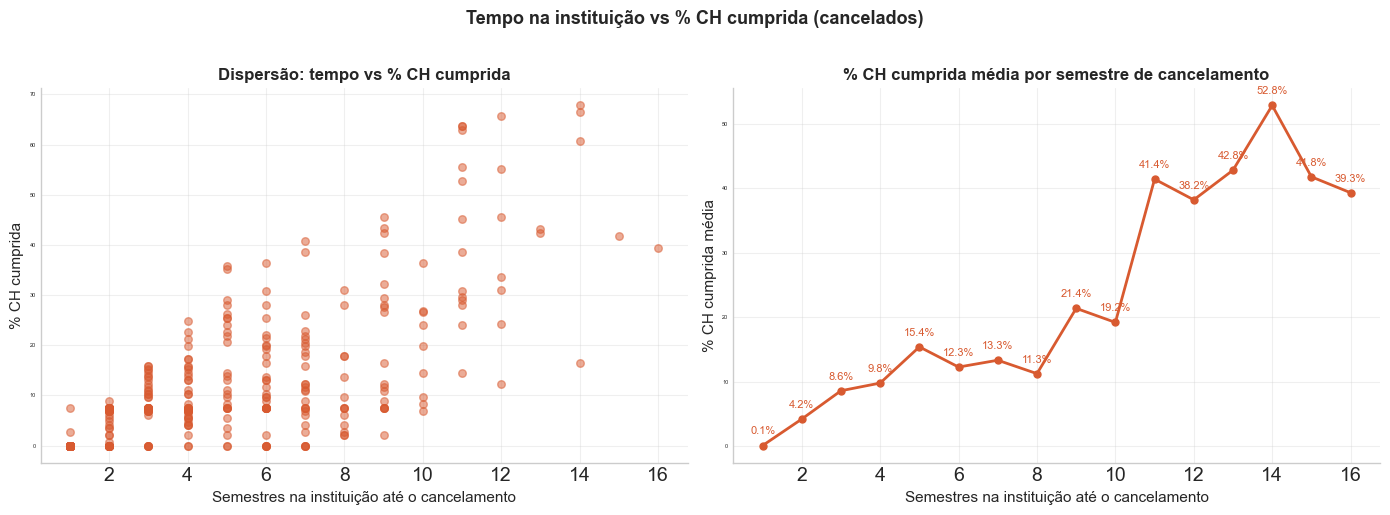

In [1373]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Dataframe: pega o valor de percentual_ch_cumprida_num por matrícula ---
# Usa o valor máximo por matrícula para garantir o percentual mais atualizado
df_ch = (
    df[df['target'] == 1]
    .groupby('matricula', as_index=False)
    .agg(
        tempo_instituicao=('tempo_instituicao', 'first'),
        percentual_ch_cumprida_num=('percentual_ch_cumprida_num', 'max')
    )
    .dropna(subset=['tempo_instituicao', 'percentual_ch_cumprida_num'])
    .reset_index(drop=True)
)

print(f"Alunos cancelados com dados completos: {len(df_ch)}")
print(df_ch['percentual_ch_cumprida_num'].describe().round(2))

# --- Visualização ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tempo na instituição vs % CH cumprida (cancelados)',
             fontsize=13, fontweight='bold', y=1.02)

# --- Gráfico 1: Scatter plot ---
ax1 = axes[0]
ax1.scatter(df_ch['tempo_instituicao'], df_ch['percentual_ch_cumprida_num'],
            color='#d85a30', alpha=0.5, s=30)
ax1.set_xlabel('Semestres na instituição até o cancelamento', fontsize=11)
ax1.set_ylabel('% CH cumprida', fontsize=11)
ax1.set_title('Dispersão: tempo vs % CH cumprida', fontsize=12)
ax1.spines[['top', 'right']].set_visible(False)

# --- Gráfico 2: % CH cumprida média por semestre de cancelamento ---
df_ch_media = (
    df_ch
    .groupby('tempo_instituicao', as_index=False)['percentual_ch_cumprida_num']
    .mean()
    .round(2)
)

ax2 = axes[1]
ax2.plot(df_ch_media['tempo_instituicao'], df_ch_media['percentual_ch_cumprida_num'],
         color='#d85a30', linewidth=2, marker='o', markersize=5)
for _, row in df_ch_media.iterrows():
    ax2.annotate(f"{row['percentual_ch_cumprida_num']:.1f}%",
                 xy=(row['tempo_instituicao'], row['percentual_ch_cumprida_num']),
                 xytext=(0, 8), textcoords='offset points',
                 ha='center', fontsize=8, color='#d85a30')
ax2.set_xlabel('Semestres na instituição até o cancelamento', fontsize=11)
ax2.set_ylabel('% CH cumprida média', fontsize=11)
ax2.set_title('% CH cumprida média por semestre de cancelamento', fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Gráfico de dispersão:**

- Alunos que cancelam cedo (semestres 1-4) têm % CH cumprida muito baixa (0-15%)
- Conforme o tempo aumenta, a % CH cumprida também aumenta — faz sentido, pois o aluno foi acumulando disciplinas antes de cancelar
- Há bastante variação — alguns alunos cancelam tarde com % CH ainda baixa

**Gráfico de média:**

- Semestre 1 → apenas 0.1% de CH cumprida — cancelaram praticamente sem cursar nada
- Crescimento progressivo até o semestre 14 (52.6%) — alunos que cancelam tarde chegaram a cumprir mais da metade do curso
- Queda nos semestres 15-16 → poucos casos, média menos confiável

**Conclusão para o target:**

- Alunos que cancelam nos primeiros 4 semestres cumprem menos de 15% da CH — são os casos mais críticos e mais fáceis de identificar precocemente
- Isso reforça que uma janela de 4 semestres captura os cancelamentos com menor CH cumprida, que são os mais impactantes

In [1374]:
# Verifica os valores únicos de periodo
print("Valores únicos de periodo:")
print(df['periodo'].value_counts(dropna=False).sort_index())

Valores únicos de periodo:
periodo
-1       528
0       3337
1       7792
2       4641
3       3478
4       3147
5       2602
6       2137
7       1080
8       1822
9       1850
10      1332
<NA>    3806
Name: count, dtype: Int64


In [1375]:
# Verifica os valores únicos de tipo_disciplina
print(df['tipo'].value_counts(dropna=False))

tipo
obrigatória    29594
NaN             3806
optativa        3625
eletiva          520
 eletiva           7
Name: count, dtype: int64


In [1376]:
# Corrige o espaço no valor ' eletiva'
df['tipo'] = df['tipo'].str.strip()

# Confirma os valores únicos após correção
print(df['tipo'].value_counts(dropna=False))

tipo
obrigatória    29594
NaN             3806
optativa        3625
eletiva          527
Name: count, dtype: int64


In [1377]:
# Converte periodo para Int64 nullable
df['periodo'] = pd.to_numeric(df['periodo'], errors='coerce').astype('Int64')

# Confirma a conversão
print(df['periodo'].dtype)
print(df['periodo'].value_counts(dropna=False).sort_index())

Int64
periodo
-1       528
0       3337
1       7792
2       4641
3       3478
4       3147
5       2602
6       2137
7       1080
8       1822
9       1850
10      1332
<NA>    3806
Name: count, dtype: Int64


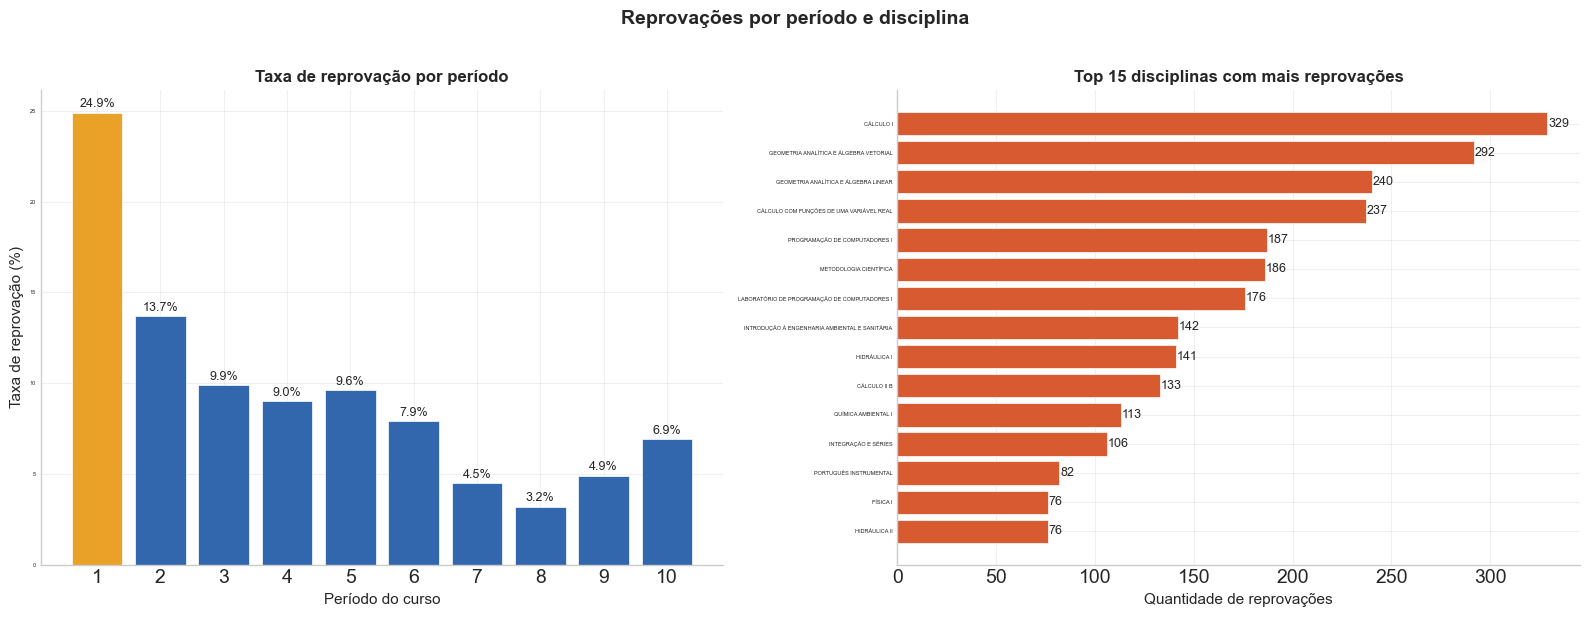

In [1378]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Visualização 1: Taxa de reprovação por período (disciplinas obrigatórias) ---

# Filtra apenas obrigatórias com período válido (1 a 10)
df_obrig = df[
    (df['tipo'] == 'obrigatória') &
    (df['periodo'].notna()) &
    (df['periodo'] >= 1)
].copy()

# Calcula taxa de reprovação por período
df_rep_periodo = (
    df_obrig
    .groupby('periodo', as_index=False)
    .apply(lambda x: pd.Series({
        'total': len(x),
        'reprovados': (x['situacao_disciplina_categoria'] == 'Reprovado').sum()
    }))
    .reset_index(drop=True)
)
df_rep_periodo['taxa_reprovacao'] = (
    df_rep_periodo['reprovados'] / df_rep_periodo['total'] * 100
).round(1)

# --- Visualização 2: Top 15 disciplinas com mais reprovações ---

df_disc_rep = (
    df_obrig[df_obrig['situacao_disciplina_categoria'] == 'Reprovado']
    .groupby('disciplina', as_index=False)['matricula']
    .count()
    .rename(columns={'matricula': 'qtd_reprovacoes'})
    .sort_values('qtd_reprovacoes', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

# --- Plot ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Reprovações por período e disciplina', fontsize=14, fontweight='bold', y=1.02)

# --- Gráfico 1: Taxa de reprovação por período ---
ax1 = axes[0]
cores = ['#d85a30' if t >= 30 else '#e9a227' if t >= 20 else '#3266ad'
         for t in df_rep_periodo['taxa_reprovacao']]
bars = ax1.bar(df_rep_periodo['periodo'].astype(int),
               df_rep_periodo['taxa_reprovacao'],
               color=cores, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, df_rep_periodo['taxa_reprovacao']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=9)
ax1.set_xlabel('Período do curso', fontsize=11)
ax1.set_ylabel('Taxa de reprovação (%)', fontsize=11)
ax1.set_title('Taxa de reprovação por período', fontsize=12)
ax1.set_xticks(df_rep_periodo['periodo'].astype(int))
ax1.spines[['top', 'right']].set_visible(False)

# --- Gráfico 2: Top 15 disciplinas com mais reprovações ---
ax2 = axes[1]
bars2 = ax2.barh(df_disc_rep['disciplina'], df_disc_rep['qtd_reprovacoes'],
                 color='#d85a30', edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, df_disc_rep['qtd_reprovacoes']):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             str(int(val)), va='center', fontsize=9)
ax2.set_xlabel('Quantidade de reprovações', fontsize=11)
ax2.set_title('Top 15 disciplinas com mais reprovações', fontsize=12)
ax2.invert_yaxis()
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Taxa de reprovação por período:**

- Período 1 destaca-se muito: 24.9% — quase 1 em cada 4 disciplinas do 1º período resulta em reprovação
- Período 2: 13.7% — ainda elevado mas cai bastante
- A partir do período 3 a taxa estabiliza entre 3-10%
- Isso reforça que o 1º período é crítico para a evasão — alto índice de reprovação logo no início pode desestimular o aluno

**Top 15 disciplinas com mais reprovações:**

- Cálculo I (329) e Geometria Analítica e Álgebra Vetorial (282) lideram com folga
- As 4 primeiras são todas de matemática/cálculo — disciplinas reconhecidamente difíceis em engenharia
- Programação de Computadores I (187) e Metodologia Científica (186) também se destacam
- A maioria do top 15 são disciplinas do 1º e 2º período — consistente com a taxa alta nesses períodos

O gráfico 3 está contando linhas — se um aluno reprovou Cálculo I 3 vezes, aparece como 3 reprovações. Para contar alunos únicos que reprovaram em cada disciplina, precisamos do nunique()

In [1379]:
# Conta alunos únicos que reprovaram em cada disciplina
df_disc_rep = (
    df_obrig[df_obrig['situacao_disciplina_categoria'] == 'Reprovado']
    .groupby('disciplina', as_index=False)['matricula']
    .nunique()
    .rename(columns={'matricula': 'qtd_alunos_reprovados'})
    .sort_values('qtd_alunos_reprovados', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print(df_disc_rep.to_string(index=False))

                                   disciplina  qtd_alunos_reprovados
                                    CÁLCULO I                    258
       GEOMETRIA ANALÍTICA E ÁLGEBRA VETORIAL                    232
                       METODOLOGIA CIENTÍFICA                    172
         GEOMETRIA ANALÍTICA E ÁLGEBRA LINEAR                    170
                PROGRAMAÇÃO DE COMPUTADORES I                    157
 LABORATÓRIO DE PROGRAMAÇÃO DE COMPUTADORES I                    155
     CÁLCULO COM FUNÇÕES DE UMA VARIÁVEL REAL                    150
INTRODUÇÃO À ENGENHARIA AMBIENTAL E SANITÁRIA                    135
                                 HIDRÁULICA I                     90
                          QUÍMICA AMBIENTAL I                     85
                          INTEGRAÇÃO E SÉRIES                     78
                                 CÁLCULO II B                     77
                       PORTUGUÊS INSTRUMENTAL                     72
                                  

In [1380]:
# Conta quantas vezes cada aluno reprovou em cada disciplina
df_rep_vezes = (
    df_obrig[df_obrig['situacao_disciplina_categoria'] == 'Reprovado']
    .groupby(['disciplina', 'matricula'], as_index=False)
    .size()
    .rename(columns={'size': 'qtd_reprovacoes'})
)

# Limita às top 15 disciplinas por alunos únicos reprovados
top15_disciplinas = df_disc_rep['disciplina'].tolist()

df_rep_vezes_top15 = df_rep_vezes[df_rep_vezes['disciplina'].isin(top15_disciplinas)].copy()

# Conta quantos alunos reprovaram 1x, 2x, 3x, 4x+ por disciplina
df_rep_vezes_top15['faixa'] = df_rep_vezes_top15['qtd_reprovacoes'].apply(
    lambda x: '1x' if x == 1 else '2x' if x == 2 else '3x' if x == 3 else '4x+'
)

df_dist_reprov = (
    df_rep_vezes_top15
    .groupby(['disciplina', 'faixa'], as_index=False)['matricula']
    .nunique()
    .rename(columns={'matricula': 'qtd_alunos'})
)

print(df_dist_reprov.head(20).to_string(index=False))

                              disciplina faixa  qtd_alunos
CÁLCULO COM FUNÇÕES DE UMA VARIÁVEL REAL    1x          96
CÁLCULO COM FUNÇÕES DE UMA VARIÁVEL REAL    2x          27
CÁLCULO COM FUNÇÕES DE UMA VARIÁVEL REAL    3x          21
CÁLCULO COM FUNÇÕES DE UMA VARIÁVEL REAL   4x+           6
                               CÁLCULO I    1x         205
                               CÁLCULO I    2x          41
                               CÁLCULO I    3x           7
                               CÁLCULO I   4x+           5
                            CÁLCULO II B    1x          44
                            CÁLCULO II B    2x          17
                            CÁLCULO II B    3x           9
                            CÁLCULO II B   4x+           7
                         GEOGRAFIA GERAL    1x          61
                         GEOGRAFIA GERAL    2x           1
    GEOMETRIA ANALÍTICA E ÁLGEBRA LINEAR    1x         119
    GEOMETRIA ANALÍTICA E ÁLGEBRA LINEAR    2x          

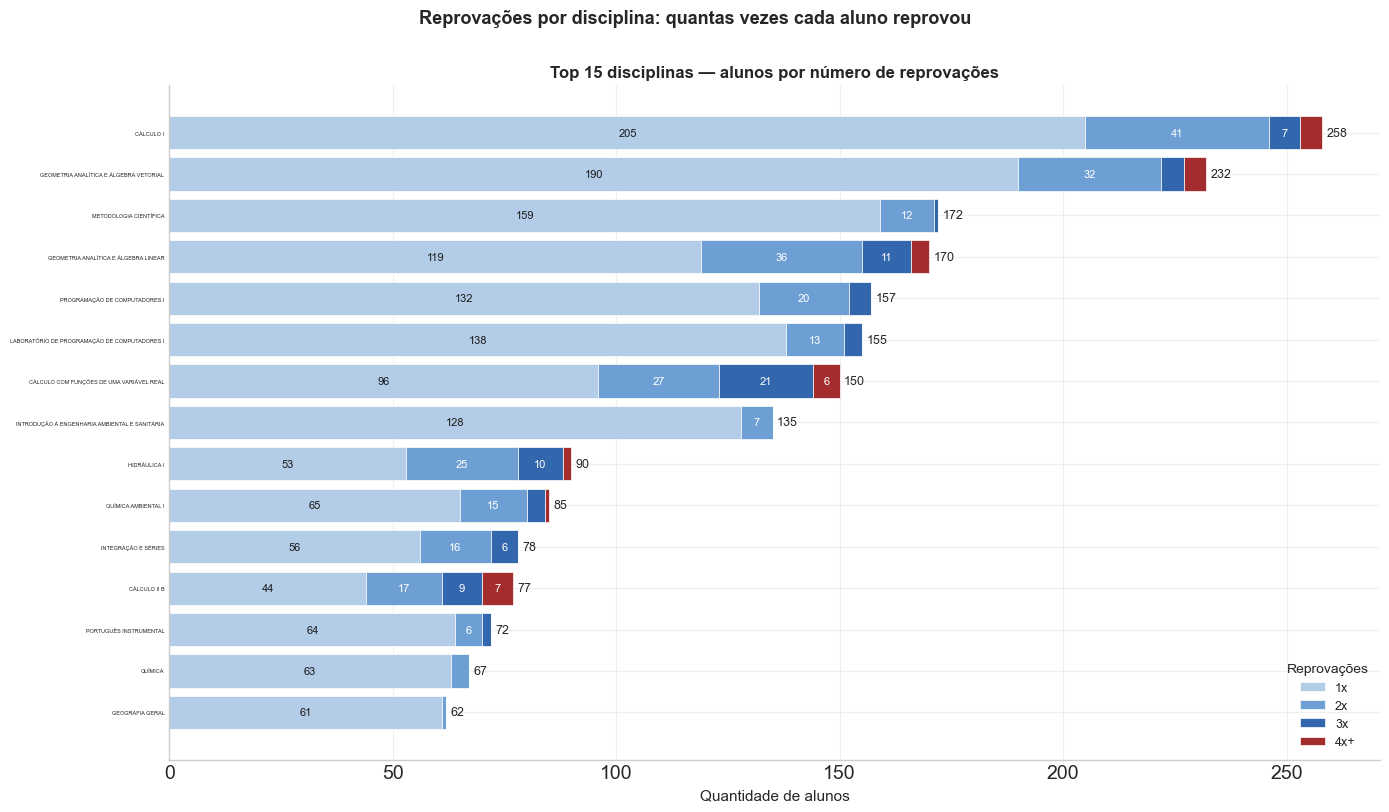

In [1381]:
import pandas as pd
import matplotlib.pyplot as plt

# Pivota para formato wide (disciplina x faixa)
df_pivot = (
    df_dist_reprov
    .pivot(index='disciplina', columns='faixa', values='qtd_alunos')
    .fillna(0)
    .astype(int)
)

# Garante a ordem das faixas
faixas = ['1x', '2x', '3x', '4x+']
df_pivot = df_pivot.reindex(columns=faixas, fill_value=0)

# Ordena pelo total de alunos únicos
df_pivot = df_pivot.loc[top15_disciplinas[::-1]]

# --- Visualização ---

fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle('Reprovações por disciplina: quantas vezes cada aluno reprovou',
             fontsize=13, fontweight='bold', y=1.01)

cores_faixas = {'1x': '#b3cde8', '2x': '#6e9fd4', '3x': '#3266ad', '4x+': '#a32d2d'}

# Cor do rótulo de acordo com o fundo: escuro para barras claras, branco para escuras
cor_rotulo = {'1x': '#1a1a1a', '2x': 'white', '3x': 'white', '4x+': 'white'}

bottom = [0] * len(df_pivot)

for faixa in faixas:
    valores = df_pivot[faixa].tolist()
    bars = ax.barh(df_pivot.index, valores, left=bottom,
                   color=cores_faixas[faixa], edgecolor='white',
                   linewidth=0.5, label=faixa)
    for bar, val, bot in zip(bars, valores, bottom):
        if val > 5:
            ax.text(bot + val / 2, bar.get_y() + bar.get_height() / 2,
                    str(int(val)), ha='center', va='center',
                    fontsize=8, color=cor_rotulo[faixa], fontweight='500')
    bottom = [b + v for b, v in zip(bottom, valores)]

# Adiciona total no final de cada barra
for i, (idx, row) in enumerate(df_pivot.iterrows()):
    total = row.sum()
    ax.text(total + 1, i, str(int(total)), va='center', fontsize=9)

ax.set_xlabel('Quantidade de alunos', fontsize=11)
ax.set_title('Top 15 disciplinas — alunos por número de reprovações', fontsize=12)
ax.legend(title='Reprovações', fontsize=9, frameon=False, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Disciplinas com mais reprovações repetidas:**

- Cálculo I → 258 alunos únicos, sendo 53 reprovaram 2x ou mais (20% repetem)
- Geometria Analítica e Álgebra Vetorial → 232 alunos, 42 repetem (18%)
- Cálculo com Funções de uma Variável Real → 150 alunos, mas 54 repetem (36%) — a maior proporção de repetição!
- Cálculo II B → 77 alunos, 33 repetem (43%) — proporção altíssima
- Hidráulica I → 90 alunos, 35 repetem (39%)

Disciplinas com baixa repetição:

- Metodologia Científica → 172 alunos mas quase todos reprovam apenas 1x (159 = 92%)
- Geografia Geral → 62 alunos, praticamente todos 1x
- Química → 67 alunos, maioria 1x

Conclusão:

- As disciplinas de cálculo não só têm mais reprovados, como também têm alta taxa de repetição — o aluno tenta várias vezes, o que pode prolongar o - - - tempo na instituição e aumentar o risco de evasão
- Metodologia Científica tem muitos reprovados mas poucos repetem — pode ser uma reprovação pontual sem grande impacto na permanência

In [1382]:
# Para cada disciplina do top 15, conta alunos únicos reprovados que cancelaram vs não cancelaram
df_rep_target = (
    df_obrig[df_obrig['situacao_disciplina_categoria'] == 'Reprovado']
    [df_obrig['disciplina'].isin(top15_disciplinas)]
    .groupby(['disciplina', 'target'], as_index=False)['matricula']
    .nunique()
    .rename(columns={'matricula': 'qtd_alunos'})
)

# Pivota para formato wide
df_rep_target_pivot = (
    df_rep_target
    .pivot(index='disciplina', columns='target', values='qtd_alunos')
    .fillna(0)
    .astype(int)
    .rename(columns={0: 'nao_cancelado', 1: 'cancelado'})
)

# Calcula total e taxa de cancelamento entre os reprovados
df_rep_target_pivot['total'] = df_rep_target_pivot['nao_cancelado'] + df_rep_target_pivot['cancelado']
df_rep_target_pivot['taxa_cancelamento'] = (
    df_rep_target_pivot['cancelado'] / df_rep_target_pivot['total'] * 100
).round(1)

# Ordena pela taxa de cancelamento
df_rep_target_pivot = df_rep_target_pivot.sort_values('taxa_cancelamento', ascending=True)

print(df_rep_target_pivot.to_string())

target                                         nao_cancelado  cancelado  total  taxa_cancelamento
disciplina                                                                                       
INTEGRAÇÃO E SÉRIES                                       70          8     78               10.3
QUÍMICA                                                   60          7     67               10.4
HIDRÁULICA I                                              80         10     90               11.1
CÁLCULO COM FUNÇÕES DE UMA VARIÁVEL REAL                 121         29    150               19.3
GEOMETRIA ANALÍTICA E ÁLGEBRA LINEAR                     135         35    170               20.6
METODOLOGIA CIENTÍFICA                                   127         45    172               26.2
CÁLCULO II B                                              55         22     77               28.6
QUÍMICA AMBIENTAL I                                       46         39     85               45.9
CÁLCULO I           

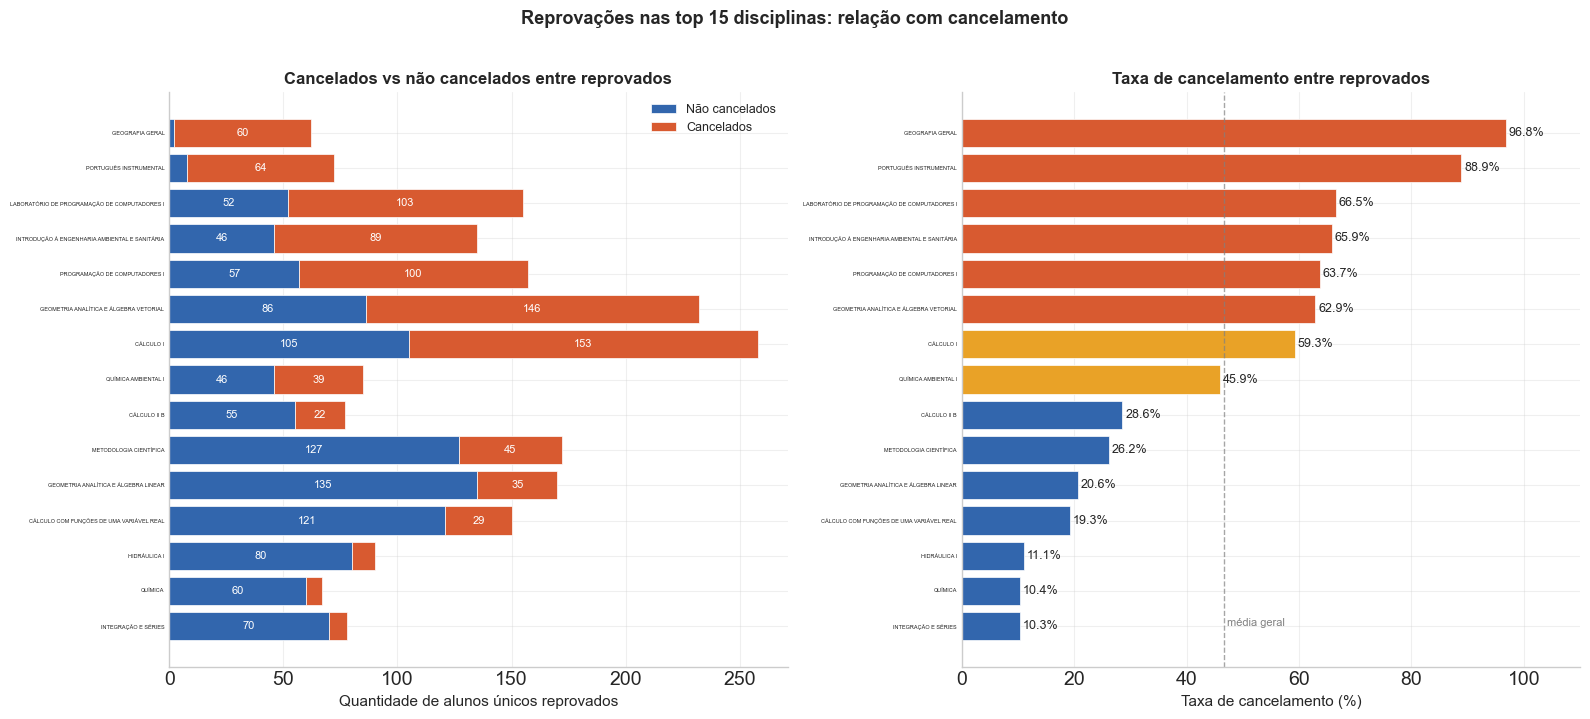

In [1383]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Reprovações nas top 15 disciplinas: relação com cancelamento',
             fontsize=13, fontweight='bold', y=1.02)

# --- Gráfico 1: Barras empilhadas (cancelados vs não cancelados) ---
ax1 = axes[0]
bars1 = ax1.barh(df_rep_target_pivot.index, df_rep_target_pivot['nao_cancelado'],
                 color='#3266ad', edgecolor='white', linewidth=0.5, label='Não cancelados')
bars2 = ax1.barh(df_rep_target_pivot.index, df_rep_target_pivot['cancelado'],
                 left=df_rep_target_pivot['nao_cancelado'],
                 color='#d85a30', edgecolor='white', linewidth=0.5, label='Cancelados')

# Rótulos dentro das barras
for bar, val in zip(bars1, df_rep_target_pivot['nao_cancelado']):
    if val > 10:
        ax1.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                 str(int(val)), ha='center', va='center', fontsize=8, color='white', fontweight='500')
for bar, val, left in zip(bars2, df_rep_target_pivot['cancelado'], df_rep_target_pivot['nao_cancelado']):
    if val > 10:
        ax1.text(left + val / 2, bar.get_y() + bar.get_height() / 2,
                 str(int(val)), ha='center', va='center', fontsize=8, color='white', fontweight='500')

ax1.set_xlabel('Quantidade de alunos únicos reprovados', fontsize=11)
ax1.set_title('Cancelados vs não cancelados entre reprovados', fontsize=12)
ax1.legend(fontsize=9, frameon=False)
ax1.spines[['top', 'right']].set_visible(False)

# --- Gráfico 2: Taxa de cancelamento entre reprovados ---
ax2 = axes[1]
cores = ['#d85a30' if t >= 60 else '#e9a227' if t >= 30 else '#3266ad'
         for t in df_rep_target_pivot['taxa_cancelamento']]
bars3 = ax2.barh(df_rep_target_pivot.index, df_rep_target_pivot['taxa_cancelamento'],
                 color=cores, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars3, df_rep_target_pivot['taxa_cancelamento']):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%', va='center', fontsize=9)

# Linha de referência na média geral de cancelamento
media_geral = df['target'].drop_duplicates().mean() * 100
ax2.axvline(x=df.drop_duplicates('matricula')['target'].mean() * 100,
            color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.text(df.drop_duplicates('matricula')['target'].mean() * 100 + 0.5,
         0, 'média geral', fontsize=8, color='gray')
ax2.set_xlabel('Taxa de cancelamento (%)', fontsize=11)
ax2.set_title('Taxa de cancelamento entre reprovados', fontsize=12)
ax2.set_xlim(0, 110)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Disciplinas com alta taxa de cancelamento entre reprovados (acima de 60%):**

- Geografia Geral: 96.8% — quase todos que reprovaram cancelaram! Mas volume baixo (62 alunos)
- Português Instrumental: 88.9% — altíssima taxa, 64 cancelados de 72
- Laboratório de Programação: 66.5% e Introdução à Engenharia: 65.9%
- Programação de Computadores I: 63.7% e Geometria Analítica Vetorial: 62.9%

**Disciplinas com volume alto E taxa alta (as mais críticas):**

- Cálculo I → 258 alunos reprovados, 59.3% cancelaram (153 alunos!) — o maior impacto absoluto
- Geometria Analítica e Álgebra Vetorial → 232 reprovados, 62.9% cancelaram (146 alunos)
- Programação de Computadores I → 157 reprovados, 63.7% cancelaram (100 alunos)

**Disciplinas com baixa taxa de cancelamento entre reprovados:**

- Integração e Séries: 10.3%, Química: 10.4%, Hidráulica I: 11.1% — reprovar nessas disciplinas não parece levar ao cancelamento

**Conclusão:**
- Reprovar em Cálculo I, Geometria Vetorial e Programação de Computadores I no início do curso é um forte preditor de evasão — tanto pelo volume quanto pela taxa.

In [1384]:
# Verifica o período e currículo de cada disciplina do top 15
df_periodo_disciplina = (
    df_obrig[df_obrig['disciplina'].isin(top15_disciplinas)]
    .groupby('disciplina', as_index=False)
    .agg(
        periodo_disciplina=('periodo', lambda x: x.mode()[0]),  # período mais frequente
        curriculo=('curriculo', lambda x: x.mode()[0])          # currículo mais frequente
    )
)

print(df_periodo_disciplina.sort_values('periodo_disciplina').to_string(index=False))

                                   disciplina  periodo_disciplina curriculo
     CÁLCULO COM FUNÇÕES DE UMA VARIÁVEL REAL                   1   AMB2023
                                    CÁLCULO I                   1      9515
                              GEOGRAFIA GERAL                   1      9515
         GEOMETRIA ANALÍTICA E ÁLGEBRA LINEAR                   1   AMB2023
       GEOMETRIA ANALÍTICA E ÁLGEBRA VETORIAL                   1      9515
                       METODOLOGIA CIENTÍFICA                   1      9515
 LABORATÓRIO DE PROGRAMAÇÃO DE COMPUTADORES I                   1      9515
INTRODUÇÃO À ENGENHARIA AMBIENTAL E SANITÁRIA                   1      9515
                PROGRAMAÇÃO DE COMPUTADORES I                   1      9515
                       PORTUGUÊS INSTRUMENTAL                   1      9515
                                 CÁLCULO II B                   2      9515
                          INTEGRAÇÃO E SÉRIES                   2   AMB2023
            

- 10 das 15 disciplinas com mais reprovações são do 1º período — isso explica perfeitamente o pico de 24.9% de reprovação no período 1 que vimos antes.

- Há dois currículos diferentes — 9515 (currículo antigo) e AMB2023 (currículo novo de 2023). Isso explica algumas diferenças no ranking:

- Cálculo com Funções de uma Variável Real e Geometria Analítica e Álgebra Linear → currículo AMB2023
- Integração e Séries e Química → também AMB2023
- Todas as demais → currículo 9515

- Isso significa que as disciplinas do AMB2023 têm menos histórico (só a partir de 2023), o que pode subestimar suas taxas de reprovação e cancelamento. Vale adicionar o currículo como informação nos gráficos?


In [1385]:
# Verifica quantos alunos únicos estão em cada currículo
print(df.drop_duplicates('matricula').groupby('curriculo')['matricula'].count())

curriculo
10549        3
9515       362
AM2023T    122
AMB2023    245
EAS2021     64
Name: matricula, dtype: int64


In [1386]:
# Verifica em quais currículos cada disciplina do top 15 aparece
df_disc_curriculo = (
    df_obrig[df_obrig['disciplina'].isin(top15_disciplinas)]
    .groupby(['disciplina', 'curriculo'], as_index=False)['matricula']
    .nunique()
    .rename(columns={'matricula': 'qtd_alunos'})
    .sort_values(['disciplina', 'qtd_alunos'], ascending=[True, False])
)

print(df_disc_curriculo.to_string(index=False))

                                   disciplina curriculo  qtd_alunos
     CÁLCULO COM FUNÇÕES DE UMA VARIÁVEL REAL   AMB2023         237
     CÁLCULO COM FUNÇÕES DE UMA VARIÁVEL REAL   AM2023T          36
     CÁLCULO COM FUNÇÕES DE UMA VARIÁVEL REAL      9515           8
     CÁLCULO COM FUNÇÕES DE UMA VARIÁVEL REAL   EAS2021           1
                                    CÁLCULO I      9515         343
                                    CÁLCULO I   AM2023T         120
                                    CÁLCULO I   EAS2021          61
                                    CÁLCULO I   AMB2023           5
                                    CÁLCULO I     10549           3
                                 CÁLCULO II B      9515         173
                                 CÁLCULO II B   AM2023T          64
                                 CÁLCULO II B   EAS2021          11
                                 CÁLCULO II B   AMB2023           2
                              GEOGRAFIA GERAL   

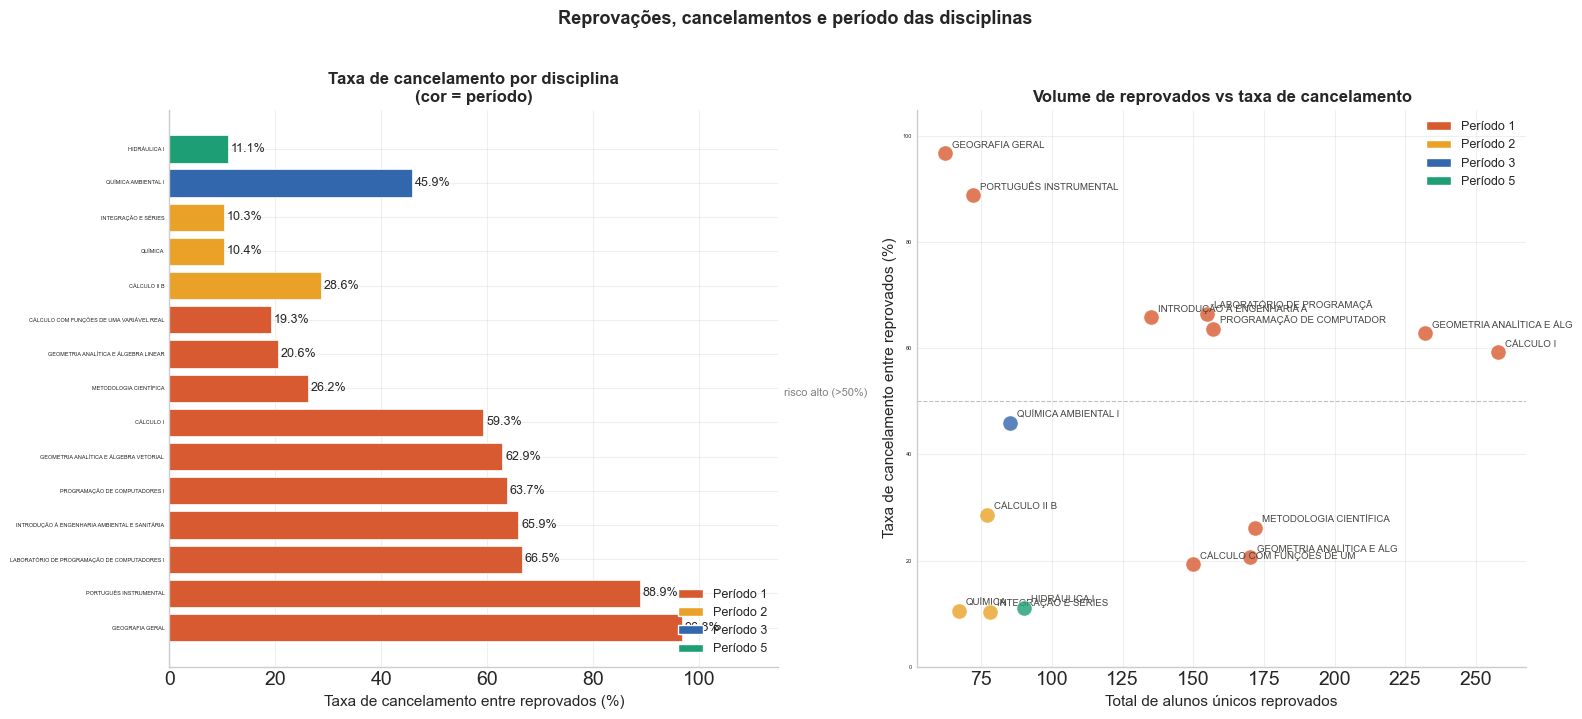

In [1387]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Junta período ao dataframe de reprovações e cancelamentos ---
df_rep_completo = df_rep_target_pivot.reset_index().merge(
    df_periodo_disciplina, on='disciplina', how='left'
)

# Ordena por período e taxa de cancelamento
df_rep_completo = df_rep_completo.sort_values(
    ['periodo_disciplina', 'taxa_cancelamento'], ascending=[True, False]
).reset_index(drop=True)

# Define cor por período
cores_periodo = {1: '#d85a30', 2: '#e9a227', 3: '#3266ad', 5: '#1d9e75'}
cores_barras = [cores_periodo.get(p, '#888780') for p in df_rep_completo['periodo_disciplina']]
legenda = [Patch(facecolor=cor, label=f'Período {p}') for p, cor in cores_periodo.items()]

# --- Visualização ---

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Reprovações, cancelamentos e período das disciplinas',
             fontsize=13, fontweight='bold', y=1.02)

# --- Gráfico 1: Taxa de cancelamento por disciplina com cor por período ---
ax1 = axes[0]
bars = ax1.barh(df_rep_completo['disciplina'], df_rep_completo['taxa_cancelamento'],
                color=cores_barras, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, df_rep_completo['taxa_cancelamento']):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%', va='center', fontsize=9)
ax1.set_xlabel('Taxa de cancelamento entre reprovados (%)', fontsize=11)
ax1.set_title('Taxa de cancelamento por disciplina\n(cor = período)', fontsize=12)
ax1.set_xlim(0, 115)
ax1.legend(handles=legenda, fontsize=9, frameon=False, loc='lower right')
ax1.spines[['top', 'right']].set_visible(False)

# --- Gráfico 2: Scatter — total de reprovados vs taxa de cancelamento ---
ax2 = axes[1]
for _, row in df_rep_completo.iterrows():
    cor = cores_periodo.get(row['periodo_disciplina'], '#888780')
    ax2.scatter(row['total'], row['taxa_cancelamento'],
                color=cor, s=120, alpha=0.8, edgecolors='white', linewidth=0.5, zorder=3)
    # Limita o nome da disciplina a 25 caracteres para evitar sobreposição
    ax2.annotate(row['disciplina'][:25],
                 xy=(row['total'], row['taxa_cancelamento']),
                 xytext=(5, 4), textcoords='offset points',
                 fontsize=7, color='#444441')

# Linha de referência em 50%
ax2.axhline(y=50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.text(5, 51, 'risco alto (>50%)', fontsize=8, color='gray')
ax2.set_xlabel('Total de alunos únicos reprovados', fontsize=11)
ax2.set_ylabel('Taxa de cancelamento entre reprovados (%)', fontsize=11)
ax2.set_title('Volume de reprovados vs taxa de cancelamento', fontsize=12)
ax2.set_ylim(0, 105)
ax2.legend(handles=legenda, fontsize=9, frameon=False)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Gráfico de barras — padrão claro por período:**

- Todas as barras vermelhas (período 1) com taxa acima de 59% — reprovar no 1º período é altamente associado ao cancelamento
- Amarelas (período 2) com taxas menores (10-46%) — menor impacto no cancelamento
- Azul (período 3) — Química Ambiental I com 45.9%, volume moderado
- Verde (período 5) — Hidráulica I com apenas 11.1% — reprovar nessa disciplina raramente leva ao cancelamento

**Scatter — quadrante crítico (alto volume + alta taxa):**

- Cálculo I → 258 reprovados, 59.3% — maior volume e alta taxa
- Geometria Analítica Vetorial → 232 reprovados, 62.9%
- Programação de Computadores I, Lab. Programação, Introdução à Engenharia → agrupados no quadrante de alto risco
- Geografia Geral e Português Instrumental → taxa altíssima mas volume baixo

**Conclusão geral:**
- Reprovar em qualquer disciplina do 1º período é um forte preditor de cancelamento — especialmente Cálculo I, Geometria Vetorial e Programação. Isso reforça que o 1º semestre é o momento mais crítico para identificar alunos em risco.

### Recomendações para definição do target

- Com base em todos os achados, as recomendações são:
- Janela de observação: 4 semestres — captura 55.5% dos cancelamentos com histórico suficiente para observar padrões de rendimento, faltas e reprovações
- Corte de safra: até 2022.1 — garante pelo menos 8 semestres de histórico para todas as safras incluídas, evitando distorção nas análises
- Features mais promissoras para o modelo:
   - Rendimento semestral (especialmente no 1º semestre)
   - Rendimento global acumulado
   - Reprovação em disciplinas do 1º período (especialmente Cálculo I, Geometria Vetorial e Programação)
   - Não renovação de matrícula
   - Sexo
   - Forma de ingresso
   - Percentual de CH cumprida
   - Anos após conclusão do ensino médio

In [1388]:
# Verifica as disciplinas do 1º período e as situações de aprovação
df_1periodo = df_obrig[df_obrig['periodo'] == 1].copy()

# Calcula o semestre na instituição em que o aluno cursou cada disciplina
df_1periodo['semestre_na_instituicao'] = df_1periodo.apply(
    lambda row: diferenca_semestres(row['safra'], row['ano_semestre_letivo']),
    axis=1
).astype('Int64')

# Filtra apenas aprovações
df_1periodo_aprov = df_1periodo[df_1periodo['situacao_disciplina_categoria'] == 'Aprovado'].copy()

# Verifica as disciplinas do 1º período disponíveis
print("Disciplinas do 1º período:")
print(df_1periodo['disciplina'].value_counts())

print(f"\nTotal de registros de aprovação no 1º período: {len(df_1periodo_aprov)}")
print(f"\nSemestre médio de aprovação por disciplina:")
print(
    df_1periodo_aprov
    .groupby('disciplina')['semestre_na_instituicao']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

Disciplinas do 1º período:
disciplina
CÁLCULO I                                        985
PROGRAMAÇÃO DE COMPUTADORES I                    982
LABORATÓRIO DE PROGRAMAÇÃO DE COMPUTADORES I     975
INTRODUÇÃO À ENGENHARIA AMBIENTAL E SANITÁRIA    902
GEOMETRIA ANALÍTICA E ÁLGEBRA VETORIAL           886
PORTUGUÊS INSTRUMENTAL                           630
CÁLCULO COM FUNÇÕES DE UMA VARIÁVEL REAL         592
GEOMETRIA ANALÍTICA E ÁLGEBRA LINEAR             575
METODOLOGIA CIENTÍFICA                           545
GEOGRAFIA GERAL                                  449
LEITURA E PRODUÇÃO DE TEXTOS ACADÊMICOS          266
FISIOLOGIA DA PAISAGEM                             4
PORTUGUÊS INSTRUMENTAL I                           1
Name: count, dtype: int64

Total de registros de aprovação no 1º período: 3417

Semestre médio de aprovação por disciplina:
disciplina
FISIOLOGIA DA PAISAGEM                           10.0
PORTUGUÊS INSTRUMENTAL I                          5.0
METODOLOGIA CIENTÍFICA        

Os dados mostram um padrão claro. Antes de montar o gráfico, vamos excluir FISIOLOGIA DA PAISAGEM e PORTUGUÊS INSTRUMENTAL I por terem volume muito baixo (4 e 1 registros). Vamos também separar por target para ver se cancelados e não cancelados levam tempos diferentes para ser aprovados

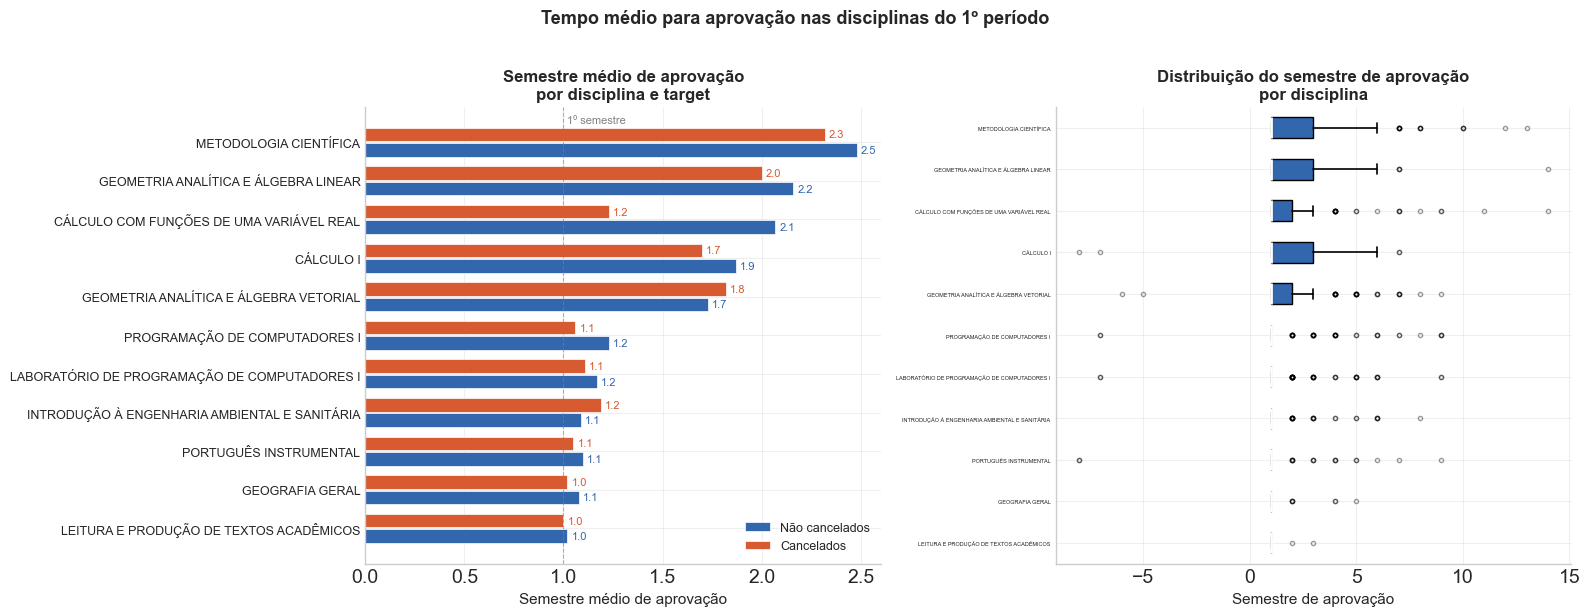

In [1389]:
import pandas as pd
import matplotlib.pyplot as plt

# Remove disciplinas com volume muito baixo
disciplinas_excluir = ['FISIOLOGIA DA PAISAGEM', 'PORTUGUÊS INSTRUMENTAL I']
df_1periodo_aprov_filtrado = df_1periodo_aprov[
    ~df_1periodo_aprov['disciplina'].isin(disciplinas_excluir)
].copy()

# Ordena pela média geral de aprovação
ordem = (
    df_1periodo_aprov_filtrado
    .groupby('disciplina')['semestre_na_instituicao']
    .mean()
    .sort_values(ascending=True)
    .index.tolist()
)

# --- Visualização ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tempo médio para aprovação nas disciplinas do 1º período',
             fontsize=13, fontweight='bold', y=1.02)

cores = {0: '#3266ad', 1: '#d85a30'}
labels = {0: 'Não cancelados', 1: 'Cancelados'}

# --- Gráfico 1: Média de semestres para aprovação por disciplina e target ---
ax1 = axes[0]
for target_val in [0, 1]:
    dados = (
        df_1periodo_aprov_filtrado[df_1periodo_aprov_filtrado['target'] == target_val]
        .groupby('disciplina', as_index=False)['semestre_na_instituicao']
        .mean()
        .rename(columns={'semestre_na_instituicao': 'media'})
        .round(2)
    )
    dados['disciplina'] = pd.Categorical(dados['disciplina'], categories=ordem, ordered=True)
    dados = dados.sort_values('disciplina').reset_index(drop=True)
    ax1.barh(
        [i + (0.2 if target_val == 1 else -0.2) for i in range(len(dados))],
        dados['media'],
        height=0.35,
        color=cores[target_val],
        label=labels[target_val],
        edgecolor='white', linewidth=0.5
    )
    for i, row in dados.iterrows():
        ax1.text(row['media'] + 0.02,
                 i + (0.2 if target_val == 1 else -0.2),
                 f'{row["media"]:.1f}',
                 va='center', fontsize=8, color=cores[target_val])

ax1.set_yticks(range(len(ordem)))
ax1.set_yticklabels(ordem, fontsize=9)
ax1.set_xlabel('Semestre médio de aprovação', fontsize=11)
ax1.set_title('Semestre médio de aprovação\npor disciplina e target', fontsize=12)
ax1.axvline(x=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax1.text(1.02, len(ordem) - 0.5, '1º semestre', fontsize=8, color='gray')
ax1.legend(fontsize=9, frameon=False)
ax1.spines[['top', 'right']].set_visible(False)

# --- Gráfico 2: Boxplot por disciplina (todos os alunos) ---
ax2 = axes[1]
dados_box = [
    df_1periodo_aprov_filtrado[
        df_1periodo_aprov_filtrado['disciplina'] == disc
    ]['semestre_na_instituicao'].dropna().astype(float).astype(int).tolist()
    for disc in ordem
]
bp = ax2.boxplot(dados_box, labels=ordem, patch_artist=True,
                 vert=False,
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(linewidth=1.2),
                 capprops=dict(linewidth=1.2),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4))
for box in bp['boxes']:
    box.set_facecolor('#3266ad')
ax2.set_xlabel('Semestre de aprovação', fontsize=11)
ax2.set_title('Distribuição do semestre de aprovação\npor disciplina', fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [1390]:
# Verifica os outliers extremos
print("Semestre máximo de aprovação por disciplina:")
print(
    df_1periodo_aprov_filtrado
    .groupby('disciplina')['semestre_na_instituicao']
    .max()
    .sort_values(ascending=False)
)

Semestre máximo de aprovação por disciplina:
disciplina
CÁLCULO COM FUNÇÕES DE UMA VARIÁVEL REAL         14
GEOMETRIA ANALÍTICA E ÁLGEBRA LINEAR             14
METODOLOGIA CIENTÍFICA                           13
PROGRAMAÇÃO DE COMPUTADORES I                     9
PORTUGUÊS INSTRUMENTAL                            9
LABORATÓRIO DE PROGRAMAÇÃO DE COMPUTADORES I      9
GEOMETRIA ANALÍTICA E ÁLGEBRA VETORIAL            9
INTRODUÇÃO À ENGENHARIA AMBIENTAL E SANITÁRIA     8
CÁLCULO I                                         7
GEOGRAFIA GERAL                                   5
LEITURA E PRODUÇÃO DE TEXTOS ACADÊMICOS           3
Name: semestre_na_instituicao, dtype: Int64


Os valores extremos fazem sentido — um aluno pode levar até 14 semestres para ser aprovado em Cálculo com Funções, o que é válido (reprovou várias vezes e persistiu). O problema do boxplot é apenas visual — os valores negativos no eixo X são causados pelo espaço para os rótulos. Vamos corrigir apenas o eixo

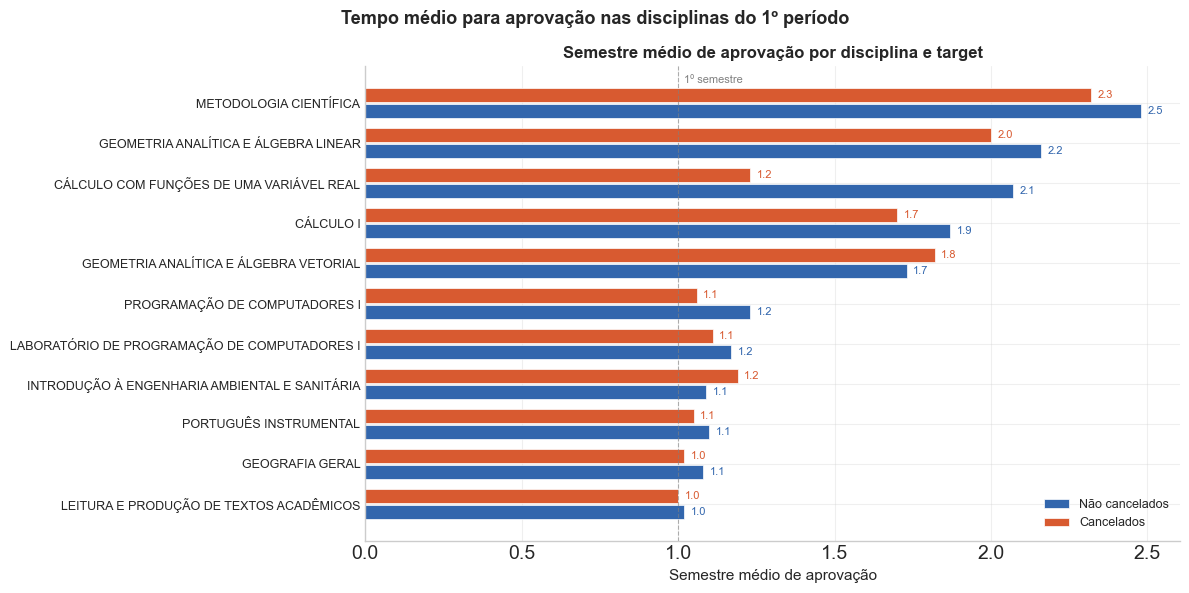

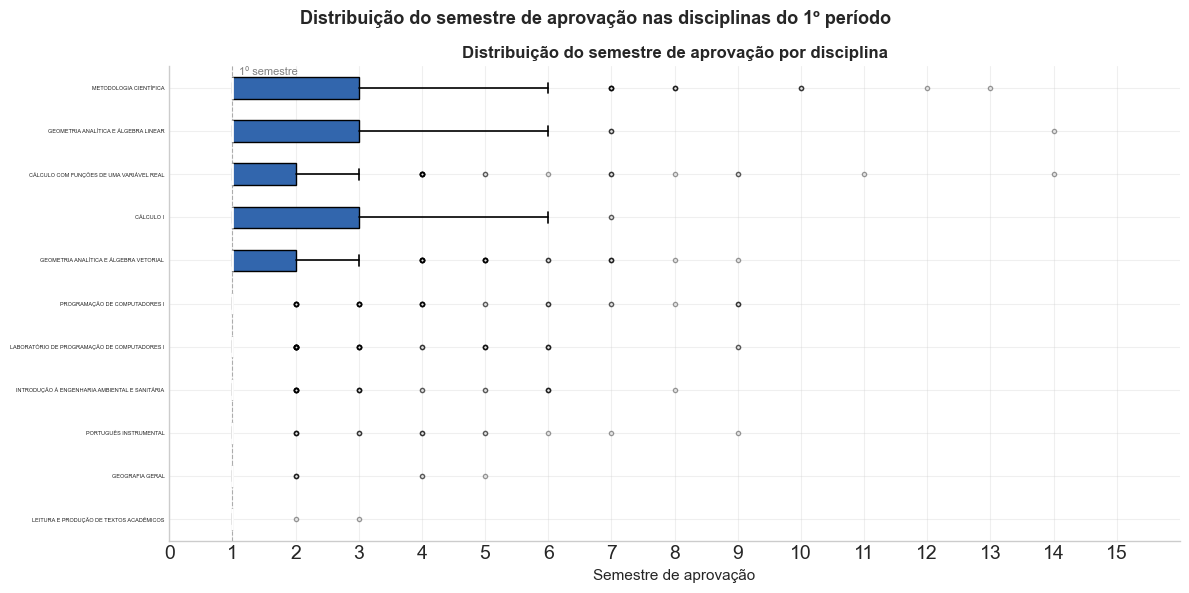

In [1391]:
import pandas as pd
import matplotlib.pyplot as plt

# Remove disciplinas com volume muito baixo
disciplinas_excluir = ['FISIOLOGIA DA PAISAGEM', 'PORTUGUÊS INSTRUMENTAL I']
df_1periodo_aprov_filtrado = df_1periodo_aprov[
    ~df_1periodo_aprov['disciplina'].isin(disciplinas_excluir)
].copy()

# Ordena pela média geral de aprovação
ordem = (
    df_1periodo_aprov_filtrado
    .groupby('disciplina')['semestre_na_instituicao']
    .mean()
    .sort_values(ascending=True)
    .index.tolist()
)

cores = {0: '#3266ad', 1: '#d85a30'}
labels = {0: 'Não cancelados', 1: 'Cancelados'}

# --- Gráfico 1: Semestre médio de aprovação por disciplina e target ---
fig1, ax1 = plt.subplots(figsize=(12, 6))
fig1.suptitle('Tempo médio para aprovação nas disciplinas do 1º período',
              fontsize=13, fontweight='bold')

for target_val in [0, 1]:
    dados = (
        df_1periodo_aprov_filtrado[df_1periodo_aprov_filtrado['target'] == target_val]
        .groupby('disciplina', as_index=False)['semestre_na_instituicao']
        .mean()
        .rename(columns={'semestre_na_instituicao': 'media'})
        .round(2)
    )
    dados['disciplina'] = pd.Categorical(dados['disciplina'], categories=ordem, ordered=True)
    dados = dados.sort_values('disciplina').reset_index(drop=True)
    ax1.barh(
        [i + (0.2 if target_val == 1 else -0.2) for i in range(len(dados))],
        dados['media'],
        height=0.35,
        color=cores[target_val],
        label=labels[target_val],
        edgecolor='white', linewidth=0.5
    )
    for i, row in dados.iterrows():
        ax1.text(row['media'] + 0.02,
                 i + (0.2 if target_val == 1 else -0.2),
                 f'{row["media"]:.1f}',
                 va='center', fontsize=8, color=cores[target_val])

ax1.set_yticks(range(len(ordem)))
ax1.set_yticklabels(ordem, fontsize=9)
ax1.set_xlabel('Semestre médio de aprovação', fontsize=11)
ax1.set_title('Semestre médio de aprovação por disciplina e target', fontsize=12)
ax1.axvline(x=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax1.text(1.02, len(ordem) - 0.5, '1º semestre', fontsize=8, color='gray')
ax1.legend(fontsize=9, frameon=False)
ax1.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# --- Gráfico 2: Boxplot por disciplina ---
fig2, ax2 = plt.subplots(figsize=(12, 6))
fig2.suptitle('Distribuição do semestre de aprovação nas disciplinas do 1º período',
              fontsize=13, fontweight='bold')

dados_box = [
    df_1periodo_aprov_filtrado[
        df_1periodo_aprov_filtrado['disciplina'] == disc
    ]['semestre_na_instituicao'].dropna().astype(float).astype(int).tolist()
    for disc in ordem
]

bp = ax2.boxplot(dados_box, labels=ordem, patch_artist=True,
                 vert=False,
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(linewidth=1.2),
                 capprops=dict(linewidth=1.2),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4))
for box in bp['boxes']:
    box.set_facecolor('#3266ad')

ax2.set_xlim(0, 16)
ax2.set_xticks(range(0, 16))
ax2.axvline(x=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax2.text(1.1, len(ordem) + 0.3, '1º semestre', fontsize=8, color='gray')
ax2.set_xlabel('Semestre de aprovação', fontsize=11)
ax2.set_title('Distribuição do semestre de aprovação por disciplina', fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

#### Gráfico de barras

- Cancelados levam mais tempo para ser aprovados em quase todas as disciplinas — especialmente em Metodologia Científica (2.5 vs 2.3), Geometria Linear (2.2 vs 2.0) e Cálculo com Funções (2.1 vs 1.2)
- Disciplinas mais "fáceis" como Leitura e Produção de Textos e Geografia Geral têm médias próximas a 1.0 para ambos os grupos

**Disciplinas com maior diferença entre cancelados e não cancelados:**

- Cálculo com Funções de uma Variável Real → cancelados levam em média 2.1 semestres vs 1.2 dos não cancelados — maior diferença (0.9 semestre)
- Metodologia Científica → cancelados: 2.5 vs não cancelados: 2.3 — ambos levam mais tempo, mas cancelados ainda mais
- Geometria Analítica e Álgebra Linear → cancelados: 2.2 vs não cancelados: 2.0
- Cálculo I → cancelados: 1.9 vs não cancelados: 1.7

**Disciplinas sem diferença relevante:**

- Leitura e Produção de Textos, Geografia Geral, Português Instrumental → ambos os grupos aprovam em média no 1º semestre — disciplinas que praticamente todos passam na primeira tentativa

**Disciplinas acima da linha do 1º semestre:**

- Metodologia Científica, Geometria Linear, Cálculo com Funções, Cálculo I e Geometria Vetorial → a média de aprovação ultrapassa o 1º semestre para ambos os grupos — confirmando que essas disciplinas exigem mais de uma tentativa para a maioria

#### Boxplot:

- Cálculo I e Metodologia Científica têm a maior dispersão — caixas largas e outliers até o semestre 7-13
- Disciplinas mais práticas (Programação, Lab. Programação, Introdução à Engenharia) têm distribuição muito concentrada no semestre 1 — quase todos aprovam na primeira tentativa
- Geometria Linear e Cálculo com Funções têm outliers extremos (até 14 semestres) — alguns alunos persistem por muitos anos tentando ser aprovados

**Disciplinas com maior dispersão (alunos levam muito tempo):**

- Metodologia Científica → caixa larga (2º ao 5º semestre), outliers até o 13º — alguns alunos persistem por anos
- Cálculo I → caixa do 1º ao 5º semestre, outlier no 7º
- Cálculo com Funções e Geometria Linear → outliers extremos até o 14º semestre — os casos mais persistentes do dataset

**Disciplinas com aprovação concentrada no 1º semestre:**

- Leitura e Produção de Textos, Geografia Geral, Português Instrumental, Introdução à Engenharia → mediana no semestre 1, praticamente sem dispersão — quase todos aprovam na primeira tentativa

**Padrão geral:**

- Disciplinas de matemática e cálculo têm distribuição mais espalhada — maior variação no tempo de aprovação
- Disciplinas de exatas aplicadas e humanas têm distribuição concentrada no semestre 1

#### Conclusão para o modelo

O tempo para aprovação nas disciplinas do 1º período — especialmente em Cálculo I, Geometria Vetorial e Cálculo com Funções — é um preditor relevante:

- Cancelados levam consistentemente mais semestres para ser aprovados
- Alunos que não conseguem ser aprovados nessas disciplinas no 1º semestre têm maior risco de evasão
- Isso reforça a importância de incluir indicadores de aprovação no 1º semestre como features no modelo preditivo

In [ ]:
qualidade = df[['matricula', 'safra', 'forma_ingresso' , 'anos_apos_em', 'rendimento_global', 'target']]
qualidade.head()

In [1394]:
def generate_metadata(dataframe):
    """
    Gera um dataframe contendo metadados das colunas do dataframe fornecido.
    :param dataframe: DataFrame para o qual os metadados serão gerados.
    :return: DataFrame contendo metadados.
    """
    # Coleta de metadados básicos
    metadata = pd.DataFrame({
        'nome_variavel': dataframe.columns,
        'tipo': dataframe.dtypes.astype(str),   # <- conversão para string resolve o erro de comparação
        'qt_nulos': dataframe.isnull().sum(),
        'percent_nulos': round((dataframe.isnull().sum() / len(dataframe)) * 100, 2),
        'cardinalidade': dataframe.nunique(),
    })
    metadata = metadata.sort_values(by='tipo')
    metadata = metadata.reset_index(drop=True)
    return metadata

metadata_qualidade = generate_metadata(qualidade)
metadata_qualidade

,nome_variavel,tipo,qt_nulos,percent_nulos,cardinalidade
0,anos_apos_em,Int64,0,0.00,38
1,target,Int64,0,0.00,2
2,rendimento_global,float64,63,0.17,596
3,matricula,object,0,0.00,796
4,safra,object,0,0.00,18
5,forma_ingresso,object,0,0.00,20


In [ ]:
nulos = df[df['rendimento_global'].isnull()]
print(f"Registros nulos: {len(nulos)}")
print(f"Alunos únicos com nulos: {nulos['matricula'].nunique()}")

In [ ]:
# --- Verifica se há nulos de rendimento_semestral no 1º semestre ---
df_alunos_1sem = df.drop_duplicates('matricula').copy()

# Filtra registros do 1º semestre na instituição
df_1sem = df[df['safra'] == 1].copy()

print("=== Nulos de rendimento_semestral no 1º semestre ===")
print(f"Total de registros no 1º semestre: {len(df_1sem)}")
print(f"Nulos em rendimento_semestral:     {df_1sem['rendimento_global'].isna().sum()}")
print(f"Percentual de nulos:               {df_1sem['rendimento_global'].isna().mean()*100:.1f}%")

In [ ]:
# --- Calcula semestre_na_instituicao no df principal ---
df['semestre_na_instituicao'] = df.apply(
    lambda row: diferenca_semestres(row['safra'], row['ano_semestre_letivo']),
    axis=1
).astype('Int64')

# --- Verifica nulos de rendimento_semestral no 1º semestre ---
df_1sem = df[df['semestre_na_instituicao'] == 1].copy()

print("=== Nulos de rendimento_global no 1º semestre ===")
print(f"Total de registros no 1º semestre:   {len(df_1sem)}")
print(f"Nulos em rendimento_global:        {df_1sem['rendimento_global'].isna().sum()}")
print(f"Percentual de nulos:                  {df_1sem['rendimento_global'].isna().mean()*100:.1f}%")

# --- Distribuição dos nulos por semestre na instituição ---
print("\n=== Nulos de rendimento_global por semestre na instituição ===")
nulos_por_sem = (
    df[df['semestre_na_instituicao'] >= 1]
    .groupby('semestre_na_instituicao')
    .agg(
        Total=('rendimento_global', 'count'),
        Nulos=('rendimento_global', lambda x: x.isna().sum())
    )
    .reset_index()
)
nulos_por_sem['Pct_Nulos_%'] = (nulos_por_sem['Nulos'] / (nulos_por_sem['Total'] + nulos_por_sem['Nulos']) * 100).round(1)
print(nulos_por_sem.to_string(index=False))

In [ ]:
# --- Verifica se há nulos de rendimento_semestral no 1º semestre ---
df_alunos_1sem = df.drop_duplicates('matricula').copy()

# Filtra registros do 1º semestre na instituição
df_1sem = df[df['safra'] == 1].copy()

print("=== Nulos de rendimento_semestral no 1º semestre ===")
print(f"Total de registros no 1º semestre: {len(df_1sem)}")
print(f"Nulos em rendimento_semestral:     {df_1sem['rendimento_semestral'].isna().sum()}")
print(f"Percentual de nulos:               {df_1sem['rendimento_semestral'].isna().mean()*100:.1f}%")

In [ ]:
# --- Calcula semestre_na_instituicao no df principal ---
df['semestre_na_instituicao'] = df.apply(
    lambda row: diferenca_semestres(row['safra'], row['ano_semestre_letivo']),
    axis=1
).astype('Int64')

# --- Verifica nulos de rendimento_semestral no 1º semestre ---
df_1sem = df[df['semestre_na_instituicao'] == 1].copy()

print("=== Nulos de rendimento_semestral no 1º semestre ===")
print(f"Total de registros no 1º semestre:   {len(df_1sem)}")
print(f"Nulos em rendimento_semestral:        {df_1sem['rendimento_semestral'].isna().sum()}")
print(f"Percentual de nulos:                  {df_1sem['rendimento_semestral'].isna().mean()*100:.1f}%")

# --- Distribuição dos nulos por semestre na instituição ---
print("\n=== Nulos de rendimento_semestral por semestre na instituição ===")
nulos_por_sem = (
    df[df['semestre_na_instituicao'] >= 1]
    .groupby('semestre_na_instituicao')
    .agg(
        Total=('rendimento_semestral', 'count'),
        Nulos=('rendimento_semestral', lambda x: x.isna().sum())
    )
    .reset_index()
)
nulos_por_sem['Pct_Nulos_%'] = (nulos_por_sem['Nulos'] / (nulos_por_sem['Total'] + nulos_por_sem['Nulos']) * 100).round(1)
print(nulos_por_sem.to_string(index=False))

In [ ]:
# --- Investiga os alunos com nulo no rendimento_semestral no 1º semestre ---
df_alunos = df.drop_duplicates('matricula').copy()

# Identifica matrículas com nulo no 1º semestre
matriculas_nulo_1sem = (
    df[
        (df['semestre_na_instituicao'] == 1) &
        (df['rendimento_semestral'].isna())
    ]['matricula']
    .unique()
)

print(f"Alunos com nulo no rendimento_semestral no 1º semestre: {len(matriculas_nulo_1sem)}")

# Verifica o target desses alunos
df_nulo_1sem = df_alunos[df_alunos['matricula'].isin(matriculas_nulo_1sem)]

print("\n=== Target dos alunos com nulo no 1º semestre ===")
contagem = df_nulo_1sem['target'].value_counts().sort_index()
total    = contagem.sum()
for idx, val in contagem.items():
    label = 'Permaneceram/Concluíram' if idx == 0 else 'Evadiram'
    print(f"  {label}: {val} ({val/total*100:.1f}%)")

# Verifica forma de ingresso desses alunos
print("\n=== Forma de ingresso dos alunos com nulo no 1º semestre ===")
print(df_nulo_1sem['forma_ingresso_categoria'].value_counts())

# Verifica se há trancamento no 1º semestre
print("\n=== Situação de trancamento dos alunos com nulo no 1º semestre ===")
print(
    df[
        (df['semestre_na_instituicao'] == 1) &
        (df['rendimento_semestral'].isna())
    ]['tipo'].value_counts(dropna=False)
)

In [ ]:
# --- Verifica situação da matrícula dos alunos com nulo no 1º semestre ---
print("=== Situação da matrícula no 1º semestre (alunos com nulo) ===")
print(
    df[
        (df['semestre_na_instituicao'] == 1) &
        (df['rendimento_semestral'].isna())
    ]['situacao_matricula'].value_counts(dropna=False)
)

# Verifica todas as situações de matrícula desses alunos no df completo
print("\n=== Situação da matrícula (todos os semestres, alunos com nulo no 1º sem) ===")
print(
    df[df['matricula'].isin(matriculas_nulo_1sem)]['situacao_matricula']
    .value_counts(dropna=False)
)

# Verifica valores únicos da coluna para garantir que estamos usando os nomes certos
print("\n=== Valores únicos de situacao_matricula ===")
print(df['situacao_matricula'].value_counts(dropna=False))

In [ ]:
# --- Investiga os 34 EM_CURSO e 13 CONCLUIDO com nulo no 1º semestre ---
df_problema = df[
    (df['semestre_na_instituicao'] == 1) &
    (df['rendimento_semestral'].isna()) &
    (df['situacao_matricula'].isin(['EM_CURSO', 'CONCLUIDO']))
].copy()

print("=== Alunos EM_CURSO ou CONCLUIDO com nulo no 1º semestre ===")
print(f"Total de registros: {len(df_problema)}")
print(f"Alunos únicos:      {df_problema['matricula'].nunique()}")

print("\n=== Situação da disciplina desses registros ===")
print(df_problema['situacao_disciplina_categoria'].value_counts(dropna=False))

print("\n=== Safra desses alunos ===")
print(df_problema['safra'].value_counts(dropna=False))

print("\n=== Target desses alunos ===")
df_prob_alunos = df.drop_duplicates('matricula')
df_prob_alunos = df_prob_alunos[df_prob_alunos['matricula'].isin(df_problema['matricula'].unique())]
print(df_prob_alunos['target'].value_counts())

In [ ]:
# --- Validação antes da imputação ---
print("=== Nulos em rendimento_semestral ANTES da imputação ===")
print(f"Total de nulos: {df['rendimento_semestral'].isna().sum()}")
print(f"Percentual:     {df['rendimento_semestral'].isna().mean()*100:.1f}%")

# --- Regra 1: CANCELADO no 1º semestre → rendimento = 0 ---
mask_regra1 = (
    (df['semestre_na_instituicao'] == 1) &
    (df['rendimento_semestral'].isna()) &
    (df['situacao_matricula'] == 'CANCELADO')
)
df.loc[mask_regra1, 'rendimento_semestral'] = 0
print(f"\nRegra 1 aplicada — CANCELADO no 1º semestre: {mask_regra1.sum()} registros imputados")

# --- Regra 2: EM_CURSO/CONCLUIDO com disciplinas Trancado/Cancelado/Indeferido → rendimento = 0 ---
mask_regra2 = (
    (df['semestre_na_instituicao'] == 1) &
    (df['rendimento_semestral'].isna()) &
    (df['situacao_matricula'].isin(['EM_CURSO', 'CONCLUIDO'])) &
    (df['situacao_disciplina_categoria'].isin(['Trancado', 'Cancelado', 'Indeferido']))
)
df.loc[mask_regra2, 'rendimento_semestral'] = 0
print(f"Regra 2 aplicada — EM_CURSO/CONCLUIDO com disciplina inativa: {mask_regra2.sum()} registros imputados")

# --- Regra 3: EM_CURSO/CONCLUIDO com NaN na situação da disciplina → investigar ---
mask_regra3 = (
    (df['semestre_na_instituicao'] == 1) &
    (df['rendimento_semestral'].isna()) &
    (df['situacao_matricula'].isin(['EM_CURSO', 'CONCLUIDO'])) &
    (df['situacao_disciplina_categoria'].isna())
)
print(f"\nRegra 3 — registros para investigação manual: {mask_regra3.sum()}")
print("\n=== Detalhamento dos registros para investigação ===")
print(
    df[mask_regra3][['matricula', 'safra', 'situacao_matricula',
                      'situacao_disciplina_categoria', 'rendimento_semestral']]
    .to_string(index=False)
)

# --- Validação após imputação ---
print("\n=== Nulos em rendimento_semestral APÓS a imputação ===")
nulos_1sem_pos = df[df['semestre_na_instituicao'] == 1]['rendimento_semestral'].isna().sum()
print(f"Nulos no 1º semestre:  {nulos_1sem_pos}")
print(f"Total de nulos no df:  {df['rendimento_semestral'].isna().sum()}")
print(f"Percentual total:      {df['rendimento_semestral'].isna().mean()*100:.1f}%")

In [ ]:
# --- Investiga os 4 registros da Regra 3 ---
matriculas_r3 = ['20203000100', '20203000422', '20253005033', '20253010211']

print("=== Histórico completo dos 4 alunos ===")
print(
    df[df['matricula'].isin(matriculas_r3)][
        ['matricula', 'safra', 'semestre_na_instituicao',
         'situacao_matricula', 'situacao_disciplina_categoria',
         'rendimento_semestral', 'target']
    ]
    .sort_values(['matricula', 'semestre_na_instituicao'])
    .to_string(index=False)
)

#### CONFIGURACOES GLOBAIS

In [1405]:
# Paleta principal de cores do projeto
# Segue convencao do Credit Scoring: verde = bom (nao evadiu), vermelho = ruim (evadiu)
COLORS = {
    'primary':   '#1A1A1A',  # texto principal
    'secondary': '#6B6B6B',  # texto secundario e elementos neutros
    'nao_evadidos':      '#647081',  # verde — aluno que permaneceu ou concluiu
    'evadidos':       '#ec8900',  # vermelho — aluno que evadiu
    'neutral':   '#455A64',  # cinza-azulado — barras de volume
    'accent':    '#1565C0',  # azul — destaque
    'light':     '#F5F5F5'   # fundo de caixas de texto
}
 
# Cores por dominio de variaveis
# Cada dominio recebe uma cor unica para facilitar a leitura visual
# nos graficos que comparam variaveis de diferentes dominios
DOMAIN_COLORS = {
    'des_': '#1565C0',  # desempenho academico  — azul
    'eng_': '#00695C',  # engajamento/frequencia — verde-escuro
    'rep_': '#C62828',  # historico de reprovacoes — vermelho
    'pro_': '#6A1B9A',  # progressao curricular  — roxo
    'tra_': '#E65100',  # trancamentos           — laranja
    'ing_': '#455A64',  # perfil de ingresso     — cinza
    'tem_': '#F9A825',  # variaveis temporais    — amarelo
}
 
# Estilo global dos graficos
# seaborn-v0_8-whitegrid: fundo branco com grade cinza suave
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor':  'white',   # fundo branco para exportacao
    'axes.titlesize':    16,
    'axes.titleweight':  'bold',
    'axes.labelsize':    13,
    'xtick.labelsize':   14,
    'ytick.labelsize':   11,
    'legend.fontsize':   12,
    'font.family':       'sans-serif',
    'axes.spines.top':   False,     # remove bordas superior e direita
    'axes.spines.right': False,     # para visual mais limpo
    'axes.grid':         True,
    'grid.alpha':        0.3        # grade suave, nao interfere na leitura
})
 
# Diretorio onde as figuras serao salvas
# Altere para o caminho desejado, ex: 'reports/figures'
FIGURES_DIR = '.'

#### FUNCOES AUXILIARES

In [1406]:
def calculate_iv(df, feature, target='target', n_bins=10):
    """
    Calcula o Information Value (IV) de uma variavel numerica.
 
    O IV mede o poder preditivo de uma variavel em relacao ao target.
    E calculado a partir do WoE (Weight of Evidence) de cada faixa da variavel.
 
    Interpretacao conforme Siddiqi (2017):
      IV < 0.02  : Nao preditivo
      0.02 - 0.1 : Fraco
      0.1  - 0.3 : Medio
      0.3  - 0.5 : Forte
      > 0.5      : Muito forte (verificar overfitting)
 
    Formula:
      WoE_i = ln(pct_nao_evadidos_i / pct_evadidos_i)
      IV = sum((pct_nao_evadidos_i - pct_evadidos_i) * WoE_i)
 
    Parametros:
      df      : DataFrame com os dados
      feature : Nome da coluna preditora
      target  : Nome da coluna target (padrao: 'target')
      n_bins  : Numero de faixas (quantis) para discretizacao
 
    Retorna:
      float: valor do IV, ou np.nan se nao for possivel calcular
    """
    # Remove linhas com valores ausentes nas colunas necessarias
    df_temp = df[[feature, target]].dropna().copy()
 
    # Exige minimo de 100 registros para calculo estatisticamente valido
    if len(df_temp) < 100:
        return np.nan
 
    # Discretiza a variavel em faixas de igual frequencia (quantis)
    # duplicates='drop' evita erro quando ha valores repetidos nos limites
    try:
        df_temp['bin'] = pd.qcut(df_temp[feature], q=n_bins, duplicates='drop')
    except ValueError:
        # Se nao conseguir criar quantis (ex: variavel binaria), usa valores unicos
        df_temp['bin'] = df_temp[feature]
 
    # Agrega contagens de Não evadido e Evadido por faixa
    grouped = df_temp.groupby('bin', observed=True).agg(
        total=(target, 'count'),
        evadidos=(target, 'sum')
    ).reset_index()
 
    grouped['nao_evadidos'] = grouped['total'] - grouped['evadidos']
 
    total_nao_evadidos = grouped['nao_evadidos'].sum()
    total_evadidos  = grouped['evadidos'].sum()
 
    # Nao e possivel calcular IV se so existe uma classe na base
    if total_nao_evadidos == 0 or total_evadidos == 0:
        return np.nan
 
    # Calcula a distribuicao percentual de nao_evadidos e evadidos por faixa
    grouped['pct_nao_evadidos'] = grouped['nao_evadidos'] / total_nao_evadidos
    grouped['pct_evadidos']  = grouped['evadidos']  / total_evadidos
 
    # Substitui zeros por valor pequeno para evitar log(0) = -infinito
    grouped['pct_nao_evadidos'] = grouped['pct_nao_evadidos'].replace(0, 0.0001)
    grouped['pct_evadidos']  = grouped['pct_evadidos'].replace(0, 0.0001)
 
    # Calcula WoE e componente de IV para cada faixa
    grouped['woe']     = np.log(grouped['pct_nao_evadidos'] / grouped['pct_evadidos'])
    grouped['iv_comp'] = (grouped['pct_nao_evadidos'] - grouped['pct_evadidos']) * grouped['woe']
 
    # IV total = soma dos componentes de todas as faixas
    return grouped['iv_comp'].sum()
 
 
def calculate_univariate_metrics(df, feature, target='target'):
    """
    Calcula as principais metricas de poder discriminatorio de uma variavel.
 
    Metricas calculadas:
      AUC  : Area Under the ROC Curve — probabilidade de ordenar corretamente
              um nao_evadidose um evadidos escolhidos aleatoriamente.
              Ajustado para sempre ser >= 0.5 (relacao inversa tambem e valida).
 
      Gini : Gini = 2 * AUC - 1
              Mede a capacidade de separacao entre nao_evadidos e evadidos.
              0% = sem discriminacao, 100% = discriminacao perfeita.
              Meta minima para credit scoring: 40% (Siddiqi, 2017).
 
      KS   : Kolmogorov-Smirnov — maxima diferenca entre a curva acumulada
              de nao_evadidos e a de evadidos. Indica o ponto de maior separacao.
 
      IV   : Information Value — poder preditivo da variavel (ver calculate_iv).
 
    Parametros:
      df      : DataFrame com os dados
      feature : Nome da coluna preditora
      target  : Nome da coluna target
 
    Retorna:
      dict com as metricas calculadas
    """
    # Remove registros com valor ausente em qualquer uma das colunas
    df_valid = df[[feature, target]].dropna()
 
    # Retorna NaN se ha poucos registros ou se a variavel nao tem variacao
    if len(df_valid) < 100 or np.std(df_valid[feature]) == 0:
        return {
            'feature':     feature,
            'auc':         np.nan,
            'gini':        np.nan,
            'ks':          np.nan,
            'iv':          np.nan,
            'pct_missing': 1 - len(df_valid) / len(df)
        }
 
    try:
        y_true  = df_valid[target].values
        y_score = df_valid[feature].values
 
        auc = roc_auc_score(y_true, y_score)
 
        # Se AUC < 0.5, a variavel tem relacao inversa com o target
        # (ex: rendimento alto = menor risco de evasao)
        # Invertemos o score para que o AUC seja sempre >= 0.5
        if auc < 0.5:
            auc     = 1 - auc
            y_score = -y_score
 
        # Calcula KS a partir da curva ROC
        # KS = max(TPR - FPR) ao longo de todos os thresholds
        fpr, tpr, _ = roc_curve(y_true, y_score)
        ks   = max(tpr - fpr) * 100   # em percentual
 
        # Gini = 2 * AUC - 1 (em percentual)
        gini = (2 * auc - 1) * 100
 
        # IV calculado separadamente
        iv = calculate_iv(df_valid, feature, target)
 
        return {
            'feature':     feature,
            'auc':         auc,
            'gini':        gini,
            'ks':          ks,
            'iv':          iv,
            'pct_missing': 1 - len(df_valid) / len(df)
        }
 
    except Exception:
        # Em caso de erro inesperado, retorna NaN para nao interromper o loop
        return {
            'feature':     feature,
            'auc':         np.nan,
            'gini':        np.nan,
            'ks':          np.nan,
            'iv':          np.nan,
            'pct_missing': 1 - len(df_valid) / len(df)
        }
 
 
def iv_interpretation(iv):
    """
    Retorna a interpretacao qualitativa do IV conforme Siddiqi (2017).
 
    Usada para adicionar uma coluna de interpretacao na tabela de metricas,
    facilitando a leitura por pessoas nao tecnicas.
    """
    if pd.isna(iv):  return 'N/A'
    elif iv < 0.02:  return 'Nao Preditivo'
    elif iv < 0.1:   return 'Fraco'
    elif iv < 0.3:   return 'Medio'
    elif iv < 0.5:   return 'Forte'
    else:            return 'Muito Forte*'  # * = verificar overfitting
 


#### Distribuição do Target


In [ ]:
df_alunos = df.drop_duplicates('matricula')

contagem = df_alunos['target'].value_counts(dropna=False).sort_index()
total = contagem.sum()

print("=== Distribuição do target (alunos únicos) ===")
for idx, val in contagem.items():
    label = 'Permaneceram / Concluíram' if idx == 0 else 'Evadiram'
    print(f"  {label} (target {idx}): {val:,} ({val/total*100:.1f}%)")
print(f"\nTotal: {total:,}")
print(f"Nulos em target: {df_alunos['target'].isna().sum()}")

In [ ]:
# Validação antes do gráfico
# Remove duplicatas para trabalhar no nível do aluno (1 linha por matrícula)
df_alunos = df.drop_duplicates('matricula')

# Preparação dos dados para o gráfico
# Ordena por índice (0 = permaneceram, 1 = evadiram) e extrai os valores
contagem = df_alunos['target'].value_counts().sort_index()
labels = ['Evadiram', 'Permaneceram']
cores  = ['#d85a30', '#e9a227']
valores = [contagem.get(1, 0), contagem.get(0, 0)]
total = sum(valores)

# Figura
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Número de estudantes que evadiram', fontsize=20, fontweight='bold', y=1.02)

# Remove grade imediatamente após criar os eixos, antes de qualquer estilo ser aplicado
ax.grid(False)

barras = ax.bar(labels, valores, color=cores, edgecolor='white', linewidth=0.5, width=0.3)

# Rótulos com valor absoluto e percentual — fontsize aumentado para 13
for barra, val in zip(barras, valores):
    pct = val / total * 100
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 5,
        f'{val}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=16  # aumentado de 10 para 13
    )

ax.set_ylabel('Nº estudantes', fontsize=16)
ax.set_ylim(0, max(valores) * 1.2)  # espaço para os rótulos
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))  # eixo Y inteiro

# Aumenta o tamanho dos rótulos dos ticks do eixo Y e X
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18)

plt.tight_layout()
plt.show()

In [ ]:
plt.close('all')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ==============================
# GRÁFICO 1 — Barras de volume
# ==============================

ax1.grid(False)

# Plota as barras e guarda o retorno para usar no bar_label
bars = ax1.bar(
    resultado['Safra (YYYY.S)'],
    resultado['Volume'],
    color='#b7bec8',
    edgecolor='white',
    linewidth=0.5
)

# Exibe o valor inteiro no topo de cada barra
ax1.bar_label(bars, fmt='%d', fontsize=14, padding=3, color='#444444')

ax1.set_title('Número de estudantes por ano/semestre de ingresso', fontsize=18, pad=15)
ax1.set_xlabel('Ingresso', fontsize=16, labelpad=15)
ax1.set_ylabel('Nº estudantes', fontsize=16)
ax1.tick_params(axis='both', labelsize=13)
ax1.spines[['top', 'right']].set_visible(False)
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Reserva espaço extra no topo para os rótulos das barras não ficarem cortados
ax1.set_ylim(0, resultado['Volume'].max() * 1.18)

# Linha de referência: média geral do volume
media_volume = resultado['Volume'].mean()
ax1.axhline(y=media_volume, color='#2E7D32', linestyle='--', linewidth=2, alpha=0.7)

# Texto da média posicionado acima da linha, no lado direito do gráfico
# O offset +3 evita sobreposição com os rótulos das barras próximas à média
# Quanto maior o número somado à media_volume, mais alto fica o texto
ax1.text(
    x=len(resultado) + 0.3,
    y=media_volume + 1.5,
    s=f'Média: {media_volume:.0f}',
    color='#000000', fontsize=14, ha='right', va='bottom'
)

# ==============================
# GRÁFICO 2 — Linha de evasão
# ==============================

ax2.grid(False)

ax2.plot(
    resultado['Safra (YYYY.S)'],
    resultado['Taxa_de_Evasao_%'],
    color='#d85a30',
    marker='o',
    markersize=5,
    linewidth=2
)

# Exibe o valor de cada ponto acima do marcador
# xytext=(0, 7) desloca o texto 7 pontos para cima em relação ao ponto
for x, y in zip(resultado['Safra (YYYY.S)'], resultado['Taxa_de_Evasao_%']):
    ax2.annotate(
        f'{y:.1f}',
        xy=(x, y),
        xytext=(0, 7),
        textcoords='offset points',
        ha='center', va='bottom',
        fontsize=14, color='#444444'
    )

ax2.set_title('Taxa de evasão por ano/semestre de ingresso', fontsize=18, pad=15)
ax2.set_xlabel('Ingresso', fontsize=16, labelpad=15)
ax2.set_ylabel('Taxa de evasão (%)', fontsize=16)
ax2.tick_params(axis='both', labelsize=13)
ax2.spines[['top', 'right']].set_visible(False)
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

# Margem inferior negativa evita que rótulos próximos de zero fiquem cortados
ax2.set_ylim(-5, resultado['Taxa_de_Evasao_%'].max() * 1.2)

# Linha de referência: média das safras consideradas maduras (2017-2022)
safras_maduras = resultado[resultado['Safra (YYYY.S)'] <= '2022.2']['Taxa_de_Evasao_%'].mean()
ax2.axhline(y=safras_maduras, color='#2E7D32', linestyle='--', linewidth=2, alpha=0.7)

# Texto da média posicionado acima da linha, no lado direito do gráfico
ax2.text(
    x=len(resultado) - 0.5,
    y=safras_maduras + 1.5,
    s=f'Média: {safras_maduras:.1f}%',
    color='#000000', fontsize=14, ha='right', va='bottom'
)

# Area sombreada abaixo da linha de evasão
ax2.fill_between(
    resultado['Safra (YYYY.S)'],
    resultado['Taxa_de_Evasao_%'],
    alpha=0.1, color='#d85a30'
)

plt.tight_layout()
plt.show()

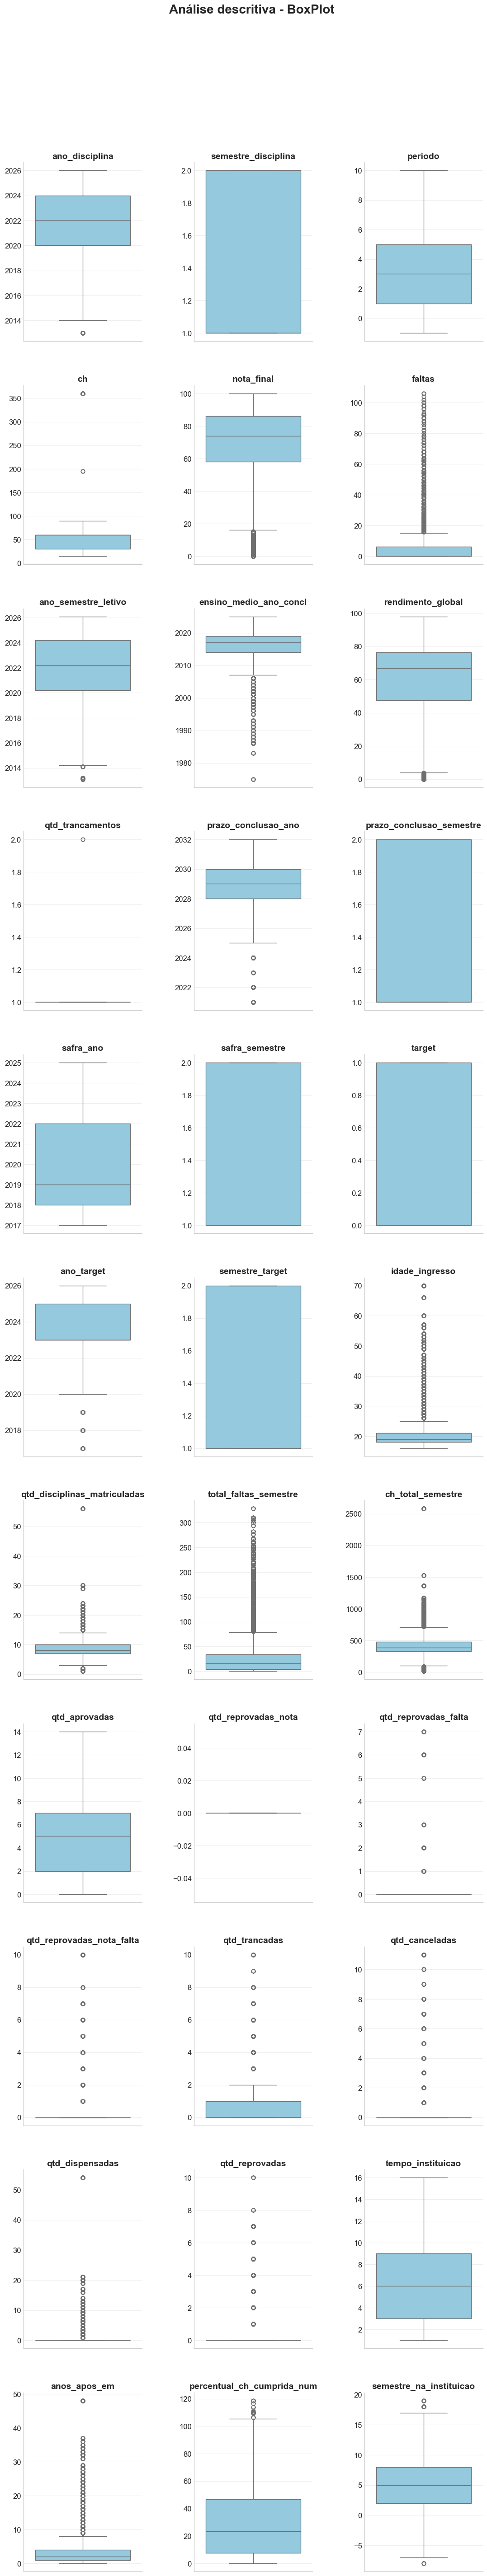

In [1427]:
def box_plot_var_num(dataframe):
    """
    Plota boxplots para todas as variáveis numéricas do dataframe fornecido
    em um painel com 3 gráficos por linha.
    Compatível com tipos float64, int64 e Int64 (nullable integer).

    :param dataframe: DataFrame para o qual os boxplots serão gerados.
    """
    # Seleciona colunas numéricas — inclui Int64 nullable usado no df
    numeric_columns = [
        col for col in dataframe.columns
        if str(dataframe[col].dtype) in ['float64', 'int64', 'Int64']
    ]

    # Define o número de linhas com base no número de colunas numéricas
    nrows = len(numeric_columns) // 3 + (len(numeric_columns) % 3 > 0)

    # Inicializa o painel de gráficos
    fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(12, nrows * 5))

    # Ajusta o layout
    plt.tight_layout(pad=5)

    # Configura estilo
    sns.set_style("whitegrid")

    # Plota boxplots para cada coluna numérica
    for i, column in enumerate(numeric_columns):
        # Converte para float para compatibilidade com seaborn (Int64 nullable pode causar erro)
        dados = dataframe[column].dropna().astype(float)
        sns.boxplot(data=dados, ax=axes[i//3, i%3], color="skyblue")
        axes[i//3, i%3].set_title(f'{column}', fontdict={'fontsize': 14, 'fontweight': 'bold'})
        axes[i//3, i%3].set_ylabel('')
        axes[i//3, i%3].tick_params(axis='both', which='major', labelsize=12)

    # Remove gráficos vazios (se houver)
    for j in range(i + 1, nrows * 3):
        fig.delaxes(axes.flatten()[j])

    # Adiciona título principal
    fig.suptitle("Análise descritiva - BoxPlot", fontsize=20, fontweight='bold', y=1.05)

    plt.show()

# Executar para df
box_plot_var_num(df)

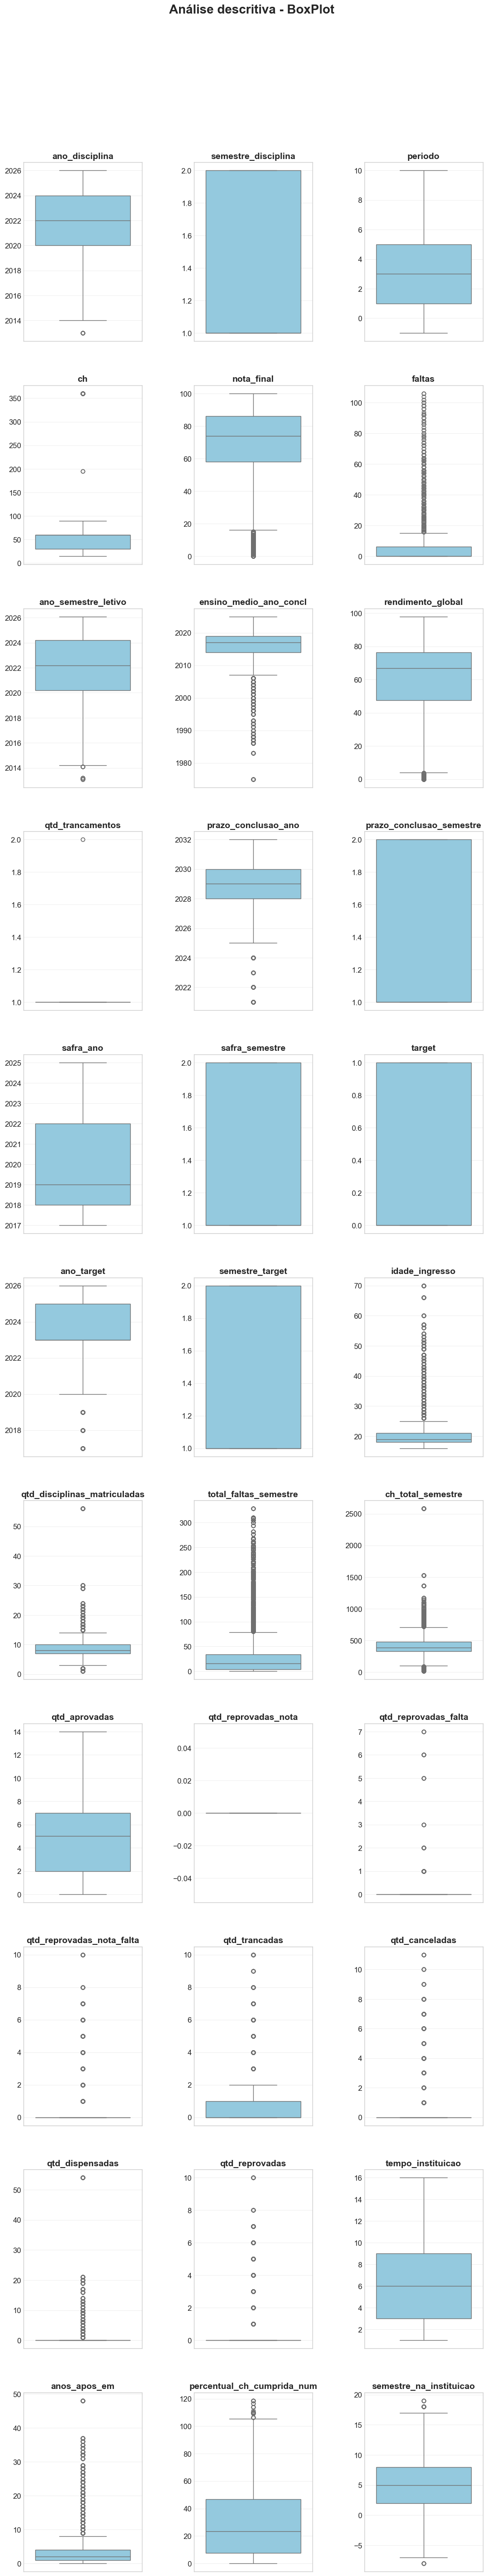

In [1428]:
# Plotando os boxplots estilizados com títulos simplificados usando a função definida
box_plot_var_num(df)

#### Analisar Outliers das Variáveis

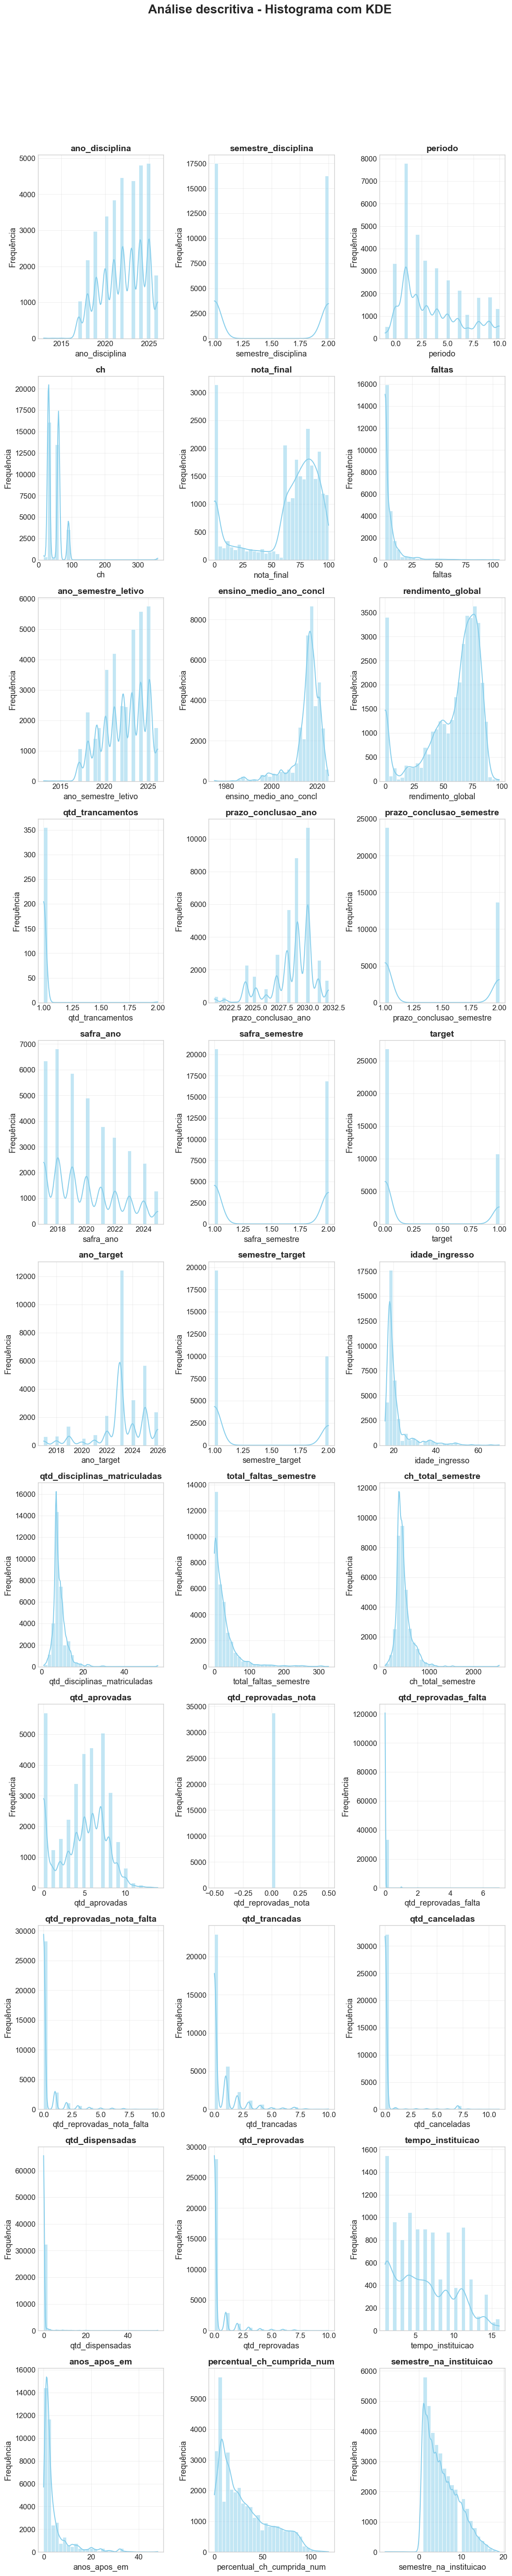

In [1429]:
def histograms_var_num(dataframe):
    """
    Plota histogramas com a curva KDE (Kernel Density Estimation) para todas as variáveis numéricas
    do dataframe fornecido em um painel com 3 gráficos por linha.
    Compatível com tipos float64, int64 e Int64 (nullable integer).

    :param dataframe: DataFrame para o qual os histogramas serão gerados.
    """
    # Seleciona colunas numéricas — inclui Int64 nullable usado no df
    numeric_columns = [
        col for col in dataframe.columns
        if str(dataframe[col].dtype) in ['float64', 'int64', 'Int64']
    ]

    # Define o número de linhas com base no número de colunas numéricas
    nrows = len(numeric_columns) // 3 + (len(numeric_columns) % 3 > 0)

    # Inicializa o painel de gráficos
    fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(12, nrows * 5))

    # Ajusta o layout
    plt.tight_layout(pad=4)

    # Configura estilo
    sns.set_style("whitegrid")

    # Plota histogramas com KDE para cada coluna numérica
    for i, column in enumerate(numeric_columns):
        # Converte para float para compatibilidade com KDE (Int64 pode causar erro no seaborn)
        dados = dataframe[column].dropna().astype(float)
        sns.histplot(data=dados, ax=axes[i//3, i%3], color="skyblue", bins=30, kde=True)
        axes[i//3, i%3].set_title(f'{column}', fontdict={'fontsize': 14, 'fontweight': 'bold'})
        axes[i//3, i%3].set_ylabel('Frequência')
        axes[i//3, i%3].tick_params(axis='both', which='major', labelsize=12)

    # Remove gráficos vazios (se houver)
    for j in range(i + 1, nrows * 3):
        fig.delaxes(axes.flatten()[j])

    # Adiciona título principal
    fig.suptitle("Análise descritiva - Histograma com KDE", fontsize=20, fontweight='bold', y=1.05)

    plt.show()

# Executar para df
histograms_var_num(df)

In [1430]:
# Definindo função de limites para outlier
# Adaptada para incluir Int64 (nullable integer) além de float64 e int64
def limites_outliers(dataframe, fator_mult_sup=1.5, fator_mult_inf=1.5):
    # fator_mult_sup e fator_mult_inf como parâmetros com valor padrão 1.5
    # permite ajustar os limites por chamada sem alterar a função

    # Tipos numéricos a considerar — inclui Int64 nullable usado no nosso df
    tipos_numericos = ['float64', 'int64', 'Int64']

    for coluna in dataframe.columns:
        if str(dataframe[coluna].dtype) in tipos_numericos:
            print(f'-> VARIÁVEL: `{coluna}`')

            q1 = dataframe[coluna].quantile(.25)
            q3 = dataframe[coluna].quantile(.75)
            IQR = q3 - q1
            print(f'IQR: {IQR}')

            # Definindo limites com fator multiplicativo ajustável
            limite_superior = q3 + 1.5 * IQR
            limite_inferior = q1 - 1.5 * IQR
            print(f'Limite superior: {limite_superior * fator_mult_sup}')
            print(f'Limite inferior: {limite_inferior * fator_mult_inf}')

            # Percentual do dataset que representa outliers
            outliers = dataframe[
                (dataframe[coluna] > (limite_superior * fator_mult_sup)) |
                (dataframe[coluna] < (limite_inferior * fator_mult_inf))
            ]
            print(f'Os outliers da variável "{coluna}" correspondem a '
                  f'{len(outliers)/dataframe.shape[0]:.2%} do dataset\n')

# Executar para todas as variáveis numéricas de df
limites_outliers(df)

-> VARIÁVEL: `ano_disciplina`
IQR: 4
Limite superior: 3045.0
Limite inferior: 3021.0
Os outliers da variável "ano_disciplina" correspondem a 89.86% do dataset

-> VARIÁVEL: `semestre_disciplina`
IQR: 1
Limite superior: 5.25
Limite inferior: -0.75
Os outliers da variável "semestre_disciplina" correspondem a 0.00% do dataset

-> VARIÁVEL: `periodo`
IQR: 4
Limite superior: 16.5
Limite inferior: -7.5
Os outliers da variável "periodo" correspondem a 0.00% do dataset

-> VARIÁVEL: `ch`
IQR: 30
Limite superior: 157.5
Limite inferior: -22.5
Os outliers da variável "ch" correspondem a 0.39% do dataset

-> VARIÁVEL: `nota_final`
IQR: 28.0
Limite superior: 192.0
Limite inferior: 24.0
Os outliers da variável "nota_final" correspondem a 12.33% do dataset

-> VARIÁVEL: `faltas`
IQR: 6.0
Limite superior: 22.5
Limite inferior: -13.5
Os outliers da variável "faltas" correspondem a 3.00% do dataset

-> VARIÁVEL: `ano_semestre_letivo`
IQR: 4.0
Limite superior: 3045.3
Limite inferior: 3021.3
Os outliers d

In [1431]:
df.describe(include='object')

,matricula,curriculo,codigo_disciplina,disciplina,disciplina_curso,tipo,situacao_disciplina,renovacao_matricula,cpf,nome,campus,curso,forma_ingresso,forma_ingresso_categoria,prazo_conclusao,sexo,nome_nacao,naturalidade_estado,naturalidade_municipio,data_nascimento,raca,ensino_medio_escola,tipo_escola,data_ingresso,dataultimamovimentacao:_dia,tipoultimamovimentacao,necessidade_especial,safra,situacao_matricula,percentual_ch_cumprida,data_trancamento_1,data_retorno_1,data_trancamento_2,data_retorno_2,ano_semestre_target,ano_semestre_conclusao,ano_semestre_integralizado,situacao_disciplina_categoria
count,37552,33759,33746,33746,32672,33746,33746,37552,37552,37552,37552,37552,37552,37552,37552,37552,37552,37497,37412,37552,35099,37509,35037,37552,29116,29116,37552,37552,35699,35699,37552,37552,37552,37552,29693,8504,2092,33746
unique,796,5,493,366,21,3,12,2,788,788,1,1,20,6,22,2,6,11,99,739,7,579,2,182,224,12,5,18,5,353,54,15,54,15,19,9,1,5
top,201722080400,9515,2DB.003,CÁLCULO I,ENGENHARIA AMBIENTAL E SANITÁRIA - BELO HORIZONTE,obrigatória,APROVADO,matriculado,"9,486,235,600",FRANCINE ANDRADE SIQUEIRA TEIXEIRA,DIRETORIA DO CAMPUS NOVA SUÍÇA - BELO HORIZONTE,ENGENHARIA AMBIENTAL E SANITÁRIA,SiSU,SISU/ENEM_AMPLA,2030.1,F,Brasil,MG,BELO HORIZONTE,"domingo, maio 11, 1997",Branco,CEFET-MG,publica,"quarta-feira, fevereiro 7, 2018","quarta-feira, fevereiro 1, 2023",CONCLUÍDO,não,2017.1,EM_CURSO,0.00%,não trancou,não trancou,não trancou,não trancou,2023.1,2025.2,2026.1,Aprovado
freq,166,19326,978,985,32133,29594,18907,33759,166,166,37552,37552,13758,25966,8790,21531,37077,36872,26833,238,13369,1556,20927,1164,7488,8504,37246,3577,13356,2643,37195,37197,37195,37197,9085,1893,2092,19606


####**Gráfico das frequências categóricas**

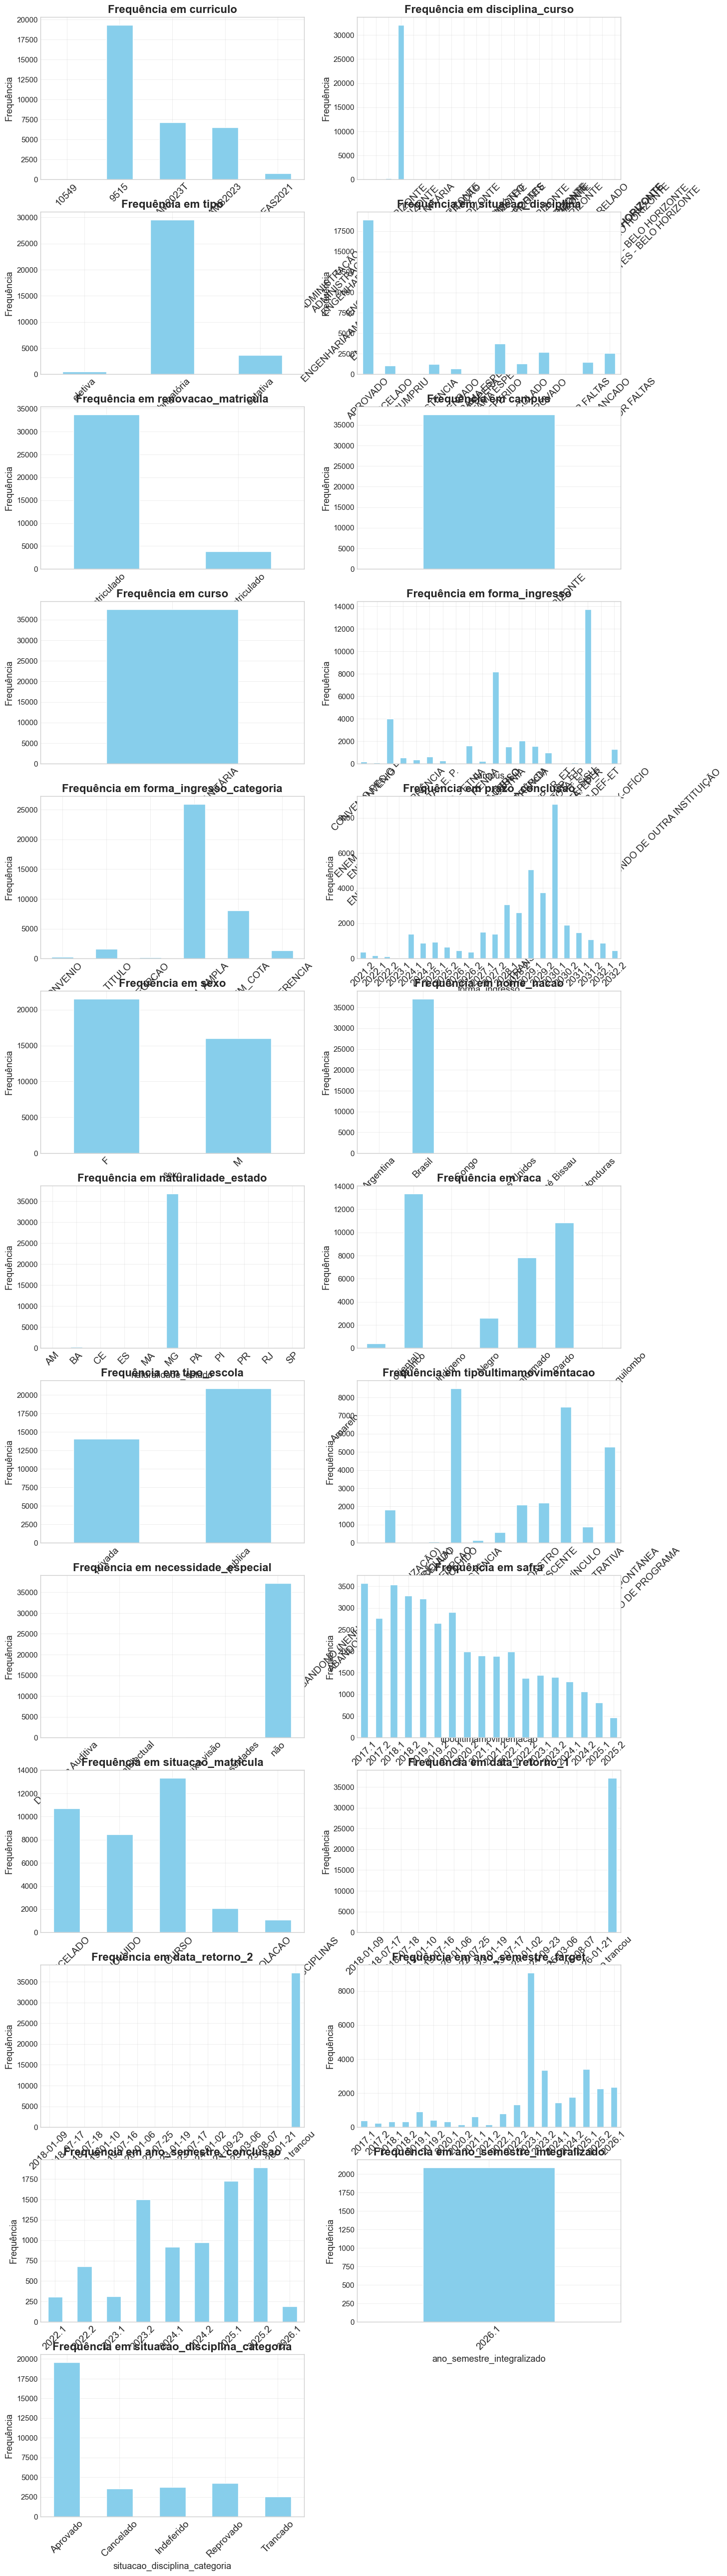

In [1432]:
def plot_categorical_frequency_pt(df, corte_cardinalidade=30, graficos_por_linha=2):
    """
    Plota a frequência de categorias para variáveis categóricas em um DataFrame.

    Parâmetros:
    - df: DataFrame para plotagem.
    - corte_cardinalidade: Cardinalidade máxima para incluir a coluna (padrão 30).
    - graficos_por_linha: Quantidade de gráficos por linha (padrão 2).
    """
    # Gera metadados do DataFrame
    metadados = []
    for coluna in df.columns:
        metadados.append({
            'Variável':      coluna,
            'Tipo':          df[coluna].dtype,
            'Cardinalidade': df[coluna].nunique()
        })
    df_metadados = pd.DataFrame(metadados)

    # Filtra colunas object com cardinalidade dentro do limite
    variaveis_categoricas = df_metadados[
        (df_metadados['Cardinalidade'] <= corte_cardinalidade) &
        (df_metadados['Tipo'] == 'object')
    ]

    # Calcula dimensões do painel
    n_linhas = -(-len(variaveis_categoricas) // graficos_por_linha)  # ceiling division
    n_colunas = min(len(variaveis_categoricas), graficos_por_linha)

    # Inicializa painel
    fig, axs = plt.subplots(nrows=n_linhas, ncols=n_colunas, figsize=(15, 5 * n_linhas))

    # Garante que axs seja sempre 2D — evita erro quando há apenas 1 linha de gráficos
    axs = np.array(axs).reshape(n_linhas, n_colunas)

    # Plota cada variável categórica
    for i, (idx, linha) in enumerate(variaveis_categoricas.iterrows()):
        var = linha['Variável']
        ax = axs[i // graficos_por_linha, i % graficos_por_linha]
        df[var].value_counts().sort_index().plot(kind='bar', ax=ax, color='skyblue')
        ax.set_title(f'Frequência em {var}')
        ax.set_ylabel('Frequência')
        ax.set_xlabel(var)
        ax.tick_params(axis='x', rotation=45)  # rotaciona labels para melhor leitura

    # Remove eixos vazios
    for j in range(i + 1, n_linhas * n_colunas):
        axs[j // graficos_por_linha, j % graficos_por_linha].axis('off')

    plt.tight_layout()
    plt.show()

# Executar para df
# corte_cardinalidade=30 já é adequado para a maioria das colunas categóricas do df
plot_categorical_frequency_pt(df, corte_cardinalidade=30, graficos_por_linha=2)

Análise multivariada

In [1433]:
print(df['rendimento_semestral'].dtype)
print(df['rendimento_semestral'].head())

Float64
0    73.692308
1         <NA>
2          0.0
3          0.0
4          0.0
Name: rendimento_semestral, dtype: Float64


In [1434]:
incluidas = [
    col for col in df.columns
    if str(df[col].dtype) in ['float64', 'int64', 'Int64']
    and col != 'target'
]
excluidas = [
    col for col in df.columns
    if str(df[col].dtype) not in ['float64', 'int64', 'Int64']
    and col != 'target'
]

print("Incluídas:", incluidas)
print("\nExcluídas:", excluidas)

Incluídas: ['ano_disciplina', 'semestre_disciplina', 'periodo', 'ch', 'nota_final', 'faltas', 'ano_semestre_letivo', 'ensino_medio_ano_concl', 'rendimento_global', 'qtd_trancamentos', 'prazo_conclusao_ano', 'prazo_conclusao_semestre', 'safra_ano', 'safra_semestre', 'ano_target', 'semestre_target', 'idade_ingresso', 'qtd_disciplinas_matriculadas', 'total_faltas_semestre', 'ch_total_semestre', 'qtd_aprovadas', 'qtd_reprovadas_nota', 'qtd_reprovadas_falta', 'qtd_reprovadas_nota_falta', 'qtd_trancadas', 'qtd_canceladas', 'qtd_dispensadas', 'qtd_reprovadas', 'tempo_instituicao', 'anos_apos_em', 'percentual_ch_cumprida_num', 'semestre_na_instituicao']

Excluídas: ['matricula', 'curriculo', 'codigo_disciplina', 'disciplina', 'disciplina_curso', 'tipo', 'situacao_disciplina', 'renovacao_matricula', 'cpf', 'nome', 'campus', 'curso', 'forma_ingresso', 'forma_ingresso_categoria', 'prazo_conclusao', 'sexo', 'nome_nacao', 'naturalidade_estado', 'naturalidade_municipio', 'data_nascimento', 'raca', '

In [1435]:
def kdeplots_var_num_target(dataframe, target_column):
    """
    Plota kdeplots para todas as variáveis numéricas discriminando pela coluna target.
    Compatível com tipos float64, int64 e Int64 (nullable integer).

    :param dataframe: DataFrame contendo as variáveis numéricas e a coluna target.
    :param target_column: Nome da coluna target binária (0 = não evadiu, 1 = evadiu).
    """
    # Seleciona colunas numéricas — inclui Int64 nullable usado no df
    numeric_columns = [
        col for col in dataframe.columns
        if str(dataframe[col].dtype) in ['float64', 'int64', 'Int64', 'Float64']
        and col != target_column  # evita plotar a própria target como variável
    ]

    # Define o número de linhas com base no número de colunas numéricas
    nrows = len(numeric_columns) // 3 + (len(numeric_columns) % 3 > 0)

    # Inicializa o painel de gráficos
    fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(14, nrows * 4))

    # Garante que axes seja sempre 2D
    axes = np.array(axes).reshape(nrows, 3)

    # Ajusta o layout
    plt.tight_layout(pad=4)

    # Configura estilo
    sns.set_style("whitegrid")

    # Plota kdeplots para cada coluna numérica discriminando pelo valor da target
    for i, column in enumerate(numeric_columns):
        # Converte para float para compatibilidade com seaborn (Int64 nullable pode causar erro)
        evadiu     = dataframe[dataframe[target_column] == 1][column].dropna().astype(float)
        nao_evadiu = dataframe[dataframe[target_column] == 0][column].dropna().astype(float)

        sns.kdeplot(data=evadidos,     ax=axes[i//3, i%3], color="red",  label="Evadiu (1)",     fill=True, warn_singular=False)
        sns.kdeplot(data=nao_evadidos, ax=axes[i//3, i%3], color="blue", label="Não evadiu (0)", fill=True, warn_singular=False)

        axes[i//3, i%3].set_title(f'{column}', fontdict={'fontsize': 14, 'fontweight': 'bold'})
        axes[i//3, i%3].set_ylabel('Densidade')
        axes[i//3, i%3].tick_params(axis='both', which='major', labelsize=12)

        if i == 0:
            axes[i//3, i%3].legend(title=target_column)

    # Remove gráficos vazios (se houver)
    for j in range(i + 1, nrows * 3):
        fig.delaxes(axes.flatten()[j])

    # Adiciona título principal
    fig.suptitle("Análise descritiva - KDE por Target", fontsize=20, fontweight='bold', y=1.00)

    plt.show()

# Executar
kdeplots_var_num_target(df, target_column='target')



NameError: name 'evadidos' is not defined

##### **Gráficos de barras segmentado**

In [ ]:
print(df['periodo'].dtype)

In [ ]:
print(df['periodo'].nunique())
print(df['periodo'].unique())

In [ ]:
# Ver o nome exato de todas as colunas
print(df.columns.tolist())

In [ ]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
categorical_columns = [col for col in categorical_columns if col != 'target']

filtered = [col for col in categorical_columns if df[col].nunique() <= 15]
print("Colunas incluídas:", filtered)

excluded = [col for col in categorical_columns if df[col].nunique() > 15]
print("Colunas excluídas:", excluded)

In [ ]:
def plot_cat_vs_target_percentage(dataframe, target_column, cutoff=15):
    categorical_columns = dataframe.select_dtypes(include=['object', 'category']).columns
    categorical_columns = [col for col in categorical_columns if col != target_column]
    categorical_columns_filtered = [
        col for col in categorical_columns
        if dataframe[col].nunique() <= cutoff
    ]

    n_rows = len(categorical_columns_filtered) // 3 + (len(categorical_columns_filtered) % 3 > 0)
    n_cols = min(len(categorical_columns_filtered), 3)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
    axes = np.array(axes).reshape(n_rows, n_cols)
    plt.tight_layout(pad=4)

    for i, column in enumerate(categorical_columns_filtered):
        print(f"Plotando coluna: {column}")
        try:
            prop_df = (
                dataframe.groupby([column, target_column]).size()
                / dataframe.groupby(column).size()
            ).unstack()

            ax = axes[i // n_cols, i % n_cols]
            prop_df.plot(kind='bar', stacked=True, ax=ax)
            ax.set_title(column, fontsize=14)
            ax.set_ylabel('Porcentagem')
            ax.tick_params(axis='both', which='major', labelsize=12)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
            plt.subplots_adjust(wspace=0.5, hspace=0.7)
            print(f"  ✓ OK")
        except Exception as e:
            print(f"  ✗ Erro: {e}")

    for j in range(len(categorical_columns_filtered), n_rows * n_cols):
        fig.delaxes(axes.flatten()[j])

    fig.suptitle(
        "Análise de Variáveis Categóricas em relação ao Target (Porcentagem)",
        fontsize=20, fontweight='bold', y=1.02
    )
    plt.show()

plot_cat_vs_target_percentage(df, target_column='target', cutoff=15)

In [ ]:
## **Utilizando Pandas_Profilling**

In [ ]:
pip install ydata-profiling

In [ ]:
# Importação correta com ydata-profiling
from ydata_profiling import ProfileReport

# Gerar relatório
profile = ProfileReport(df, title='EDA - Evasão CEFET', explorative=True)

# Exibir no Jupyter
profile.to_notebook_iframe()

# Ou salvar como HTML
profile.to_file('eda_evasao_cefet.html')

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
"""
verificar_duplicatas.py
========================
Verifica se as colunas suspeitas de duplicação no df_alunos são realmente redundantes.
Execute em seu Jupyter notebook:
    exec(open('verificar_duplicatas.py').read())
Ou cole diretamente em uma célula.
"""

import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# AJUSTE: informe o nome do seu DataFrame aqui
# ─────────────────────────────────────────────────────────────────────────────
df = df  # <── altere se necessário

# ─────────────────────────────────────────────────────────────────────────────
# Utilitários
# ─────────────────────────────────────────────────────────────────────────────
SEP = "─" * 65

def cabecalho(titulo):
    print(f"\n{SEP}")
    print(f"  {titulo}")
    print(SEP)

def resultado(ok, detalhe=""):
    status = " REDUNDANTE – pode remover" if ok else " DIVERGE – investigar"
    print(f"  {status}")
    if detalhe:
        print(f"  {detalhe}")


# ═════════════════════════════════════════════════════════════════════════════
# 1. percentual_ch_cumprida (object) × percentual_ch_cumprida_num (float)
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("1. percentual_ch_cumprida × percentual_ch_cumprida_num")

pct_str = (
    df["percentual_ch_cumprida"]
    .str.rstrip("%")
    .astype(float)
)
diff_pct = (pct_str - df["percentual_ch_cumprida_num"]).abs().max()
ok = diff_pct < 0.01
resultado(ok, f"Diferença máxima entre as colunas: {diff_pct:.6f}")
print("  → Manter: percentual_ch_cumprida_num  |  Remover: percentual_ch_cumprida")


# ═════════════════════════════════════════════════════════════════════════════
# 2. situacao_disciplina × situacao_disciplina_categoria
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("2. situacao_disciplina → situacao_disciplina_categoria")

mapeamento_esperado = {
    "APROVADO":                        "Aprovado",
    "REPROVADO POR NOTA":              "Reprovado",
    "REPROVADO POR FALTAS":            "Reprovado",
    "REPROVADO POR MÉDIA E POR FALTAS":"Reprovado",
    "TRANCADO":                        "Trancado",
    "CANCELADO":                       "Cancelado",
    "DISPENSADO":                      "Aprovado",   # ajuste se necessário
    "INDEFERIDO":                      "Indeferido",
}

df_check = df[["situacao_disciplina", "situacao_disciplina_categoria"]].dropna()
df_check = df_check.assign(
    categoria_derivada=df_check["situacao_disciplina"].map(mapeamento_esperado)
)

divergencias = df_check[
    df_check["categoria_derivada"] != df_check["situacao_disciplina_categoria"]
]

ok = len(divergencias) == 0
resultado(ok, f"Divergências encontradas: {len(divergencias)}")

if not ok:
    print("\n  Pares com divergência:")
    print(
        divergencias
        .groupby(["situacao_disciplina", "situacao_disciplina_categoria", "categoria_derivada"])
        .size()
        .rename("n")
        .reset_index()
        .to_string(index=False)
    )

# Mostra também os valores únicos para revisar o mapeamento
print("\n  Tabela de frequência (granular → categoria):")
print(
    df_check
    .groupby(["situacao_disciplina", "situacao_disciplina_categoria"])
    .size()
    .rename("n")
    .reset_index()
    .to_string(index=False)
)


# ═════════════════════════════════════════════════════════════════════════════
# 3. forma_ingresso × forma_ingresso_categoria
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("3. forma_ingresso → forma_ingresso_categoria")

print("  Tabela de frequência (forma → categoria):")
print(
    df.groupby(["forma_ingresso", "forma_ingresso_categoria"])
    .size()
    .rename("n")
    .reset_index()
    .sort_values("forma_ingresso")
    .to_string(index=False)
)
print("  → Verifique se cada forma_ingresso mapeia para UMA única categoria.")
n_categorias_por_forma = (
    df.groupby("forma_ingresso")["forma_ingresso_categoria"].nunique()
)
ok = (n_categorias_por_forma == 1).all()
resultado(ok, "Cada forma_ingresso possui exatamente uma categoria?" + (" Sim." if ok else " Não."))


# ═════════════════════════════════════════════════════════════════════════════
# 4. safra_ano + safra_semestre → safra
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("4. safra_ano + safra_semestre → safra")

safra_derivada = (
    df["safra_ano"].astype(str) + "." + df["safra_semestre"].astype(str)
)
divergencias = (safra_derivada != df["safra"]).sum()
ok = divergencias == 0
resultado(ok, f"Registros divergentes: {divergencias}")
if not ok:
    print(df[safra_derivada != df["safra"]][["safra_ano", "safra_semestre", "safra"]].head())


# ═════════════════════════════════════════════════════════════════════════════
# 5. prazo_conclusao_ano + prazo_conclusao_semestre → prazo_conclusao
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("5. prazo_conclusao_ano + prazo_conclusao_semestre → prazo_conclusao")

prazo_derivado = (
    df["prazo_conclusao_ano"].astype(str) + "." + df["prazo_conclusao_semestre"].astype(str)
)
divergencias = (prazo_derivado != df["prazo_conclusao"]).sum()
ok = divergencias == 0
resultado(ok, f"Registros divergentes: {divergencias}")
if not ok:
    print(df[prazo_derivado != df["prazo_conclusao"]][
        ["prazo_conclusao_ano", "prazo_conclusao_semestre", "prazo_conclusao"]
    ].head())


# ═════════════════════════════════════════════════════════════════════════════
# 6. ano_disciplina + semestre_disciplina → ano_semestre_letivo
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("6. ano_disciplina + semestre_disciplina → ano_semestre_letivo")

letivo_derivado = (
    df["ano_disciplina"].astype(float) + df["semestre_disciplina"].astype(float) / 10
)
diff = (letivo_derivado - df["ano_semestre_letivo"]).abs().max()
ok = diff < 0.001
resultado(ok, f"Diferença máxima: {diff:.6f}")
if not ok:
    mask = (letivo_derivado - df["ano_semestre_letivo"]).abs() > 0.001
    print(df[mask][["ano_disciplina", "semestre_disciplina", "ano_semestre_letivo"]].head())


# ═════════════════════════════════════════════════════════════════════════════
# 7. ano_target + semestre_target → ano_semestre_target
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("7. ano_target + semestre_target → ano_semestre_target")

mask_notna = df["ano_target"].notna() & df["semestre_target"].notna()
target_derivado = (
    df.loc[mask_notna, "ano_target"].astype(int).astype(str)
    + "."
    + df.loc[mask_notna, "semestre_target"].astype(int).astype(str)
)
divergencias = (target_derivado != df.loc[mask_notna, "ano_semestre_target"]).sum()
ok = divergencias == 0
resultado(ok, f"Registros divergentes (excluindo nulos): {divergencias}")
if not ok:
    mask_div = target_derivado != df.loc[mask_notna, "ano_semestre_target"]
    print(df.loc[mask_notna][mask_div][
        ["ano_target", "semestre_target", "ano_semestre_target"]
    ].head())


# ═════════════════════════════════════════════════════════════════════════════
# 8. semestre_na_instituicao × tempo_instituicao
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("8. semestre_na_instituicao × tempo_instituicao")

mask_ambos = df["semestre_na_instituicao"].notna() & df["tempo_instituicao"].notna()
sub = df.loc[mask_ambos, ["semestre_na_instituicao", "tempo_instituicao"]]

print(f"  Registros com ambas preenchidas: {mask_ambos.sum()} de {len(df)}")
print(f"  semestre_na_instituicao — únicos: {sub['semestre_na_instituicao'].nunique()}, "
      f"range: {sub['semestre_na_instituicao'].min()} – {sub['semestre_na_instituicao'].max()}")
print(f"  tempo_instituicao       — únicos: {sub['tempo_instituicao'].nunique()}, "
      f"range: {sub['tempo_instituicao'].min()} – {sub['tempo_instituicao'].max()}")

# Testa hipótese: tempo_instituicao = semestre_na_instituicao / 2
razao = (sub["semestre_na_instituicao"] / sub["tempo_instituicao"]).describe()
print(f"\n  Razão semestre/tempo:\n{razao.to_string()}")
corr = sub["semestre_na_instituicao"].corr(sub["tempo_instituicao"])
print(f"\n  Correlação de Pearson: {corr:.4f}")
if corr > 0.95:
    print("    Alta correlação — provavelmente medem o mesmo conceito em escalas diferentes.")
else:
    print("  Correlação baixa — parecem medir conceitos distintos. Manter ambas.")


# ═════════════════════════════════════════════════════════════════════════════
# 9. data_trancamento_1 × data_trancamento_2 | data_retorno_1 × data_retorno_2
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("9. Pares de trancamento (_1 × _2)")

for par in [("data_trancamento_1", "data_trancamento_2"),
            ("data_retorno_1", "data_retorno_2")]:
    c1, c2 = par
    iguais = (df[c1] == df[c2]).sum()
    diff2_real = (df[c2] != "não trancou").sum()
    print(f"\n  {c1} × {c2}")
    print(f"    Registros idênticos entre as duas:       {iguais} / {len(df)}")
    print(f"    Registros em _2 com data real (≠ 'não trancou'): {diff2_real}")
    if diff2_real == 0:
        print("     _2 é sempre 'não trancou' — remover com segurança.")
    else:
        print(f"     {diff2_real} alunos tiveram 2º trancamento. Avaliar se é relevante.")


# ═════════════════════════════════════════════════════════════════════════════
# 10. Colunas constantes (variância zero)
# ═════════════════════════════════════════════════════════════════════════════
cabecalho("10. Colunas constantes (1 valor único)")

constantes = [
    "renovacao_matricula",
    "campus",
    "curso",
    "qtd_trancamentos",
    "ano_semestre_integralizado",
]

for col in constantes:
    n_uniq = df[col].nunique(dropna=False)
    pct_nulo = df[col].isna().mean() * 100
    valores = df[col].dropna().unique()
    print(f"\n  {col}")
    print(f"    Valores únicos (c/ nulo): {n_uniq}  |  % nulo: {pct_nulo:.1f}%")
    print(f"    Valores: {list(valores)[:5]}")
    if n_uniq <= 2:
        print("  Constante — zero variância preditiva. Remover.")
    else:
        print("   Mais de 1 valor único — revisar antes de remover.")


# ═════════════════════════════════════════════════════════════════════════════
# RESUMO FINAL
# ═════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*65}")
print("  RESUMO – Colunas candidatas à remoção após confirmação")
print(f"{'═'*65}")
candidatas = {
    "Formato duplicado":        ["percentual_ch_cumprida"],
    "Versão agrupada":          ["situacao_disciplina_categoria", "forma_ingresso_categoria"],
    "Coluna composta (= partes)":["safra", "prazo_conclusao", "ano_semestre_letivo", "ano_semestre_target"],
    "Soma de componentes":      ["qtd_reprovadas"],
    "Near-constantes":          ["renovacao_matricula", "campus", "curso",
                                 "qtd_trancamentos", "ano_semestre_integralizado"],
}
for grupo, cols in candidatas.items():
    print(f"\n  [{grupo}]")
    for c in cols:
        print(f"    • {c}")

print(f"\n{SEP}")
print("  Script concluído.")
print(SEP)

In [ ]:
# ─────────────────────────────────────────────────────────────────
# Remoção de colunas redundantes — df_alunos
# ─────────────────────────────────────────────────────────────────

colunas_remover = {

    # Formato duplicado: string com % → manter a numérica
    "formato_duplicado": [
        "percentual_ch_cumprida",
    ],

    # Versões agrupadas: deriváveis das granulares
    "versao_agrupada": [
        "situacao_disciplina_categoria",
        "forma_ingresso_categoria",
    ],

    # Componentes numéricos: deriváveis das colunas compostas mantidas
    # safra_ano + safra_semestre  →  safra
    # prazo_conclusao_ano/semestre  →  prazo_conclusao
    # ano_disciplina + semestre_disciplina  →  ano_semestre_letivo
    # ano_target + semestre_target  →  ano_semestre_target
    "componentes_numericos": [
        "safra_ano",
        "safra_semestre",
        "prazo_conclusao_ano",
        "prazo_conclusao_semestre",
        "ano_disciplina",
        "semestre_disciplina",
        "ano_target",
        "semestre_target",
    ],

    # Soma de componentes: qtd_reprovadas = nota + falta + nota_falta
    "soma_componentes": [
        "qtd_reprovadas",
    ],

    # Duplicatas literais: _1 e _2 são idênticas em todos os registros
    # Os 2 alunos com 2º trancamento têm o mesmo valor em _1 e _2
    # → manter _1, remover _2
    "duplicatas_literais": [
        "data_trancamento_2",
        "data_retorno_2",
        
    # Constantes: variância zero, sem poder preditivo
    "constantes": [
        "renovacao_matricula",
        "qtd_trancamentos",
        "ano_semestre_integralizado",
    ],
}

# Achata o dicionário em lista única
todas_remover = [col for cols in colunas_remover.values() for col in cols]

# Verifica se todas existem antes de remover
ausentes = [c for c in todas_remover if c not in df_alunos.columns]
if ausentes:
    print(f"Colunas não encontradas no DataFrame: {ausentes}")
else:
    shape_antes = df_alunos.shape
    df_alunos = df_alunos.drop(columns=todas_remover)
    shape_depois = df_alunos.shape

    print(f" Remoção concluída")
    print(f"   Colunas removidas : {shape_antes[1] - shape_depois[1]}")
    print(f"   Shape antes       : {shape_antes}")
    print(f"   Shape depois      : {shape_depois}")
    print(f"\nColunas restantes ({shape_depois[1]}):")
    print(df_alunos.columns.tolist())

In [ ]:
def gerar_dicionario_dados(dataframe):
    """
    Gera um dicionário de dados com metadados das colunas do dataframe fornecido.
    """
    registros = []

    for col in dataframe.columns:
        registros.append({
            'Coluna':             col,
            'Tipo_Dado':          str(dataframe[col].dtype),
            'Valores_Unicos':     dataframe[col].nunique(),
            'Total_Registros':    len(dataframe),
            'Nulos':              dataframe[col].isnull().sum(),
            'Percentual_Nulos':   round(dataframe[col].isnull().mean() * 100, 2),
            'Amostra_Valores':    dataframe[col].dropna().unique()[:5].tolist(),
            'Descricao':          ''   # preencher manualmente depois
        })

    dicionario = pd.DataFrame(registros)
    dicionario = dicionario.sort_values(by='Tipo_Dado').reset_index(drop=True)

    return dicionario


dicionario_df_alunos = gerar_dicionario_dados(df_alunos)
dicionario_df_alunos

In [ ]:
caminho_saida = r'C:\Users\clari\Desktop\Ciência de dados\Portfolio\Evasão\Cefet\Modelo\nova_suica\eng_amb\data_lake\003_trusted\dicionario_df_alunos.xlsx'

dicionario_df_alunos.to_excel(caminho_saida, index=False)

print(f'Arquivo salvo em: {caminho_saida}')